Cell 01 — 环境配置 + 依赖安装

In [1]:
# Cell 01  环境配置 + 依赖安装
import sys

print("Installing / verifying dependencies...")
!{sys.executable} -m pip install -q \
    xgboost lightgbm shap openpyxl statsmodels

import xgboost, lightgbm, shap, sklearn, statsmodels
print(f"  xgboost     {xgboost.__version__}")
print(f"  lightgbm    {lightgbm.__version__}")
print(f"  shap        {shap.__version__}")
print(f"  sklearn     {sklearn.__version__}")
print(f"  statsmodels {statsmodels.__version__}")
print("Cell 01 complete ✓")


Installing / verifying dependencies...
  xgboost     2.1.4
  lightgbm    4.6.0
  shap        0.49.1
  sklearn     1.0.2
  statsmodels 0.13.2
Cell 01 complete ✓


Cell 02 — 全局设置

In [2]:
# Cell 02  全局设置（颜色 / 字体 / 路径 / 工具函数）
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 颜色常量 ─────────────────────────────────────────────────────────
COLOR_ORANGE = "#FF7F00"
COLOR_BLUE   = "#20AAED"
COLOR_GREEN  = "#1DB954"
COLOR_GRAY   = "#444444"
COLOR_RED    = "#E74C3C"

MODEL_COLORS = {
    "Ridge":        "#AAAAAA",
    "RandomForest": COLOR_ORANGE,
    "MLP":          "#CCCCCC",
    "XGBoost":      COLOR_BLUE,
    "LightGBM":     COLOR_GREEN,
}

# ── matplotlib 全局参数 ───────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "Arial",
    "axes.linewidth":     1.2,
    "axes.labelsize":     11,
    "axes.titlesize":     12,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "savefig.dpi":        900,
    "figure.dpi":         150,
})

# ── 输出目录 ──────────────────────────────────────────────────────────
OUTDIR = "Outputs for Nku-MXene-20260320"
os.makedirs(OUTDIR, exist_ok=True)

# ── 工具函数 ──────────────────────────────────────────────────────────
def save_fig(name, dpi_png=300, dpi_tiff=1200):
    """保存 PNG + TIFF 两个版本"""
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, name + ".png"),
                bbox_inches="tight", dpi=dpi_png)
    try:
        plt.savefig(os.path.join(OUTDIR, name + ".tiff"),
                    bbox_inches="tight", dpi=dpi_tiff,
                    format="tiff",
                    pil_kwargs={"compression": "tiff_lzw"})
    except TypeError:
        plt.savefig(os.path.join(OUTDIR, name + ".tiff"),
                    bbox_inches="tight", dpi=dpi_tiff, format="tiff")
    print(f"  Saved: {name}.png / .tiff")

RANDOM_STATE = 42

print(f"Output directory : {os.path.abspath(OUTDIR)}")
print(f"Random state     : {RANDOM_STATE}")
print("Cell 02 complete ✓")


Output directory : D:\Jupyter\Outputs for Nku-MXene-20260320
Random state     : 42
Cell 02 complete ✓


Cell 03 — 数据加载 + 清洗

In [3]:
# Cell 03  数据加载 + 清洗
print("=" * 60)
print("Cell 03: Data Loading & Cleaning")
print("=" * 60)

DATA_PATH  = r'C:\Users\weili\Desktop\Database.xlsx'
SHEET_NAME = 0

# 列名常量
COL_M = "M_label"
COL_X = "X_label"
COL_T = "T_label"
COL_N = "n"
COL_Y = "Wf_cal"

# ── 加载 ──────────────────────────────────────────────────────────────
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Raw shape: {df_raw.shape}")

# ── 终端标签标准化 ────────────────────────────────────────────────────
def normalize_T(x):
    if pd.isna(x): return x
    s = str(x).strip().upper().replace("*","").replace("-","")
    if s in ["F","F2","FT","FTERM"]:  return "F"
    if s in ["O","O2","OT","OTERM"]:  return "O"
    if s in ["OH","OHT","OHTERM"]:    return "OH"
    return str(x).strip()

df = df_raw.copy()
df[COL_T] = df[COL_T].apply(normalize_T)
df[COL_Y] = pd.to_numeric(df[COL_Y], errors="coerce")

# ── 删除缺失关键列的行 ────────────────────────────────────────────────
key_cols = [COL_M, COL_X, COL_T, COL_N, COL_Y]
before = len(df)
df = df.dropna(subset=key_cols).reset_index(drop=True)
after = len(df)

print(f"After dropping missing: {before} → {after} samples")
print(f"Unique M : {df[COL_M].nunique()}  → {sorted(df[COL_M].unique())}")
print(f"Unique X : {df[COL_X].nunique()}  → {sorted(df[COL_X].unique())}")
print(f"Unique T : {df[COL_T].nunique()}  → {sorted(df[COL_T].unique())}")
print(f"n range  : {df[COL_N].min()} – {df[COL_N].max()}")
print(f"WF range : {df[COL_Y].min():.3f} – {df[COL_Y].max():.3f} eV")
display(df.head(3))

# ── 保存清洗后数据集信息 ──────────────────────────────────────────────
df_info = pd.DataFrame({
    "Column":  df.columns,
    "Dtype":   [str(df[c].dtype) for c in df.columns],
    "N_unique":[df[c].nunique() for c in df.columns],
    "N_null":  [df[c].isnull().sum() for c in df.columns],
})
df_info.to_csv(
    os.path.join(OUTDIR, "SI_dataset_column_info.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: SI_dataset_column_info.csv")
print("Cell 03 complete ✓")


Cell 03: Data Loading & Cleaning
Raw shape: (197, 25)
After dropping missing: 197 → 197 samples
Unique M : 11  → ['Cr', 'Hf', 'Mo', 'Nb', 'Sc', 'Ta', 'Ti', 'V', 'W', 'Y', 'Zr']
Unique X : 2  → ['C', 'N']
Unique T : 3  → ['F', 'O', 'OH']
n range  : 1 – 3
WF range : 1.348 – 7.272 eV


,name,n,M_label,X_label,T_label,a,d,VBM_PBE,CBM_PBE,Eg_PBE,...,En_X,En_T,r_M,r_X,r_T,Ip_M,Ip_X,Ip_T,Wf_cal,HoF
0,Cr2CF2,1,Cr,C,F,2.697,5.174,-3.339,-3.339,0.0,...,2.55,3.98,42.7,59.6,64,6.7660,11.2603,17.42,4.300603,-1.236000
1,Hf2CF2,1,Hf,C,F,3.157,5.482,-1.219,-1.219,0.0,...,2.55,3.98,82.9,59.6,64,6.8250,11.2603,17.42,3.630109,-1.503967
2,Mo2CF2,1,Mo,C,F,2.885,5.680,-2.895,-2.895,0.0,...,2.55,3.98,70.2,59.6,64,7.0942,11.2603,17.42,5.867242,-0.881747


Saved: SI_dataset_column_info.csv
Cell 03 complete ✓


Cell 04 — 特征工程 + 数据集构建

Cell 04: Feature Engineering
Categorical features (3) : ['M_label', 'X_label', 'T_label']
Numerical features  (19) : ['n', 'a', 'd', 'VBM_PBE', 'CBM_PBE', 'Eg_PBE', 'VBM_PBE0', 'CBM_PBE0', 'Eg_PBE0', 'IsGap', 'En_M', 'En_X', 'En_T', 'r_M', 'r_X', 'r_T', 'Ip_M', 'Ip_X', 'Ip_T']
X shape : (197, 22)
y shape : (197,)
y range : 1.348 - 7.272 eV
  Saved: Fig00_WF_distribution.png / .tiff


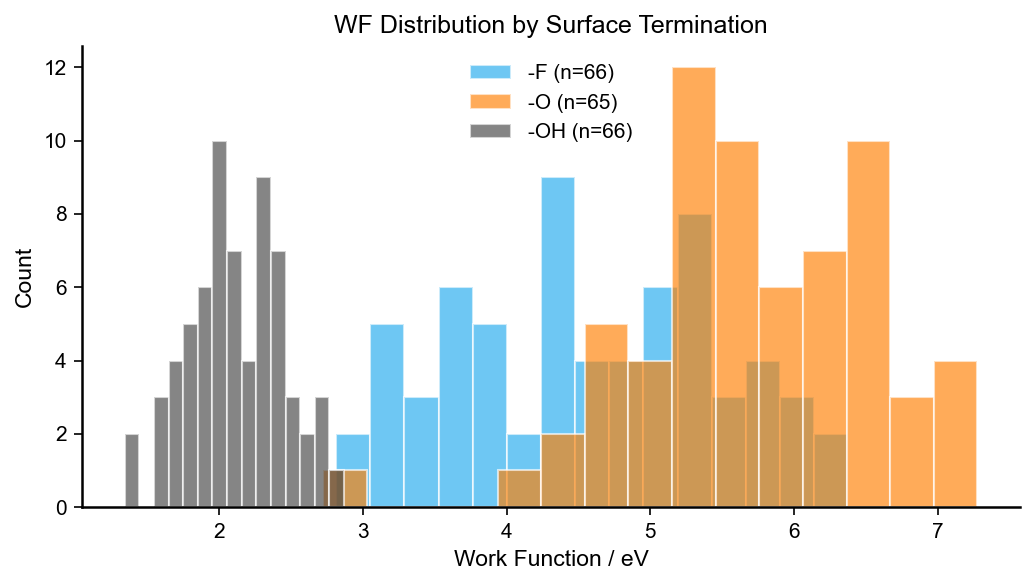


WF statistics by termination:
  -F  n=66  mean=4.569  std=0.924  min=2.816  max=6.376 eV
  -O  n=65  mean=5.718  std=0.842  min=2.725  max=7.272 eV
  -OH  n=66  mean=2.122  std=0.333  min=1.348  max=2.871 eV

Saved: Fig00_WF_raw.csv
Saved: Fig00_WF_hist_by_termination.csv
 BinCenter_eV  BinWidth_eV  Count_F  Count_O  Count_OH
      1.54515      0.39495        0        0         9
      1.94010      0.39495        0        0        27
      2.33505      0.39495        0        0        23
      2.72999      0.39495        1        1         7
      3.12494      0.39495        7        0         0
      3.51989      0.39495        8        0         0
      3.91484      0.39495        6        1         0
      4.30978      0.39495       10        2         0
      4.70473      0.39495        8        6         0
      5.09968      0.39495        8        9         0
      5.49463      0.39495       10       14         0
      5.88957      0.39495        5        8         0
      6.284

In [4]:
# Cell 04  特征工程 + 数据集构建
print("=" * 60)
print("Cell 04: Feature Engineering")
print("=" * 60)

from sklearn.compose     import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ── 特征列定义 ────────────────────────────────────────────────────────
exclude_cols = {COL_Y, COL_M, COL_X, COL_T, "HoF", "name"}
cat_cols     = [COL_M, COL_X, COL_T]

num_cols = [
    c for c in df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(df[c])
]
if "n" in num_cols:
    num_cols.remove("n")
    num_cols = ["n"] + num_cols
num_cols = list(dict.fromkeys(num_cols))

print("Categorical features (" + str(len(cat_cols)) + ") : " + str(cat_cols))
print("Numerical features  (" + str(len(num_cols)) + ") : " + str(num_cols))

# ── 特征矩阵 + 目标向量 ───────────────────────────────────────────────
X = df[cat_cols + num_cols].copy()
y = df[COL_Y].values

# ── 预处理 Pipeline ───────────────────────────────────────────────────
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

print("X shape : " + str(X.shape))
print("y shape : " + str(y.shape))
print("y range : " + str(round(float(y.min()), 3)) + " - " + str(round(float(y.max()), 3)) + " eV")

# ── WF 分布图（按终端分色）───────────────────────────────────────────
term_colors = {"F": COLOR_BLUE, "O": COLOR_ORANGE, "OH": COLOR_GRAY}

fig, ax = plt.subplots(figsize=(7, 4))

for term in ["F", "O", "OH"]:
    mask  = df[COL_T] == term
    label = "-" + term + " (n=" + str(int(mask.sum())) + ")"
    ax.hist(
        y[mask], bins=15,
        alpha=0.65,
        color=term_colors[term],
        edgecolor="white",
        label=label
    )

ax.set_xlabel("Work Function / eV")
ax.set_ylabel("Count")
ax.set_title("WF Distribution by Surface Termination")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_fig("Fig00_WF_distribution")
plt.show()

# ── 各终端统计摘要 ────────────────────────────────────────────────────
print("")
print("WF statistics by termination:")
for term in ["F", "O", "OH"]:
    mask = df[COL_T] == term
    wf_t = y[mask]
    print(
        "  -" + term +
        "  n=" + str(len(wf_t)) +
        "  mean=" + str(round(float(wf_t.mean()), 3)) +
        "  std="  + str(round(float(wf_t.std()),  3)) +
        "  min="  + str(round(float(wf_t.min()),  3)) +
        "  max="  + str(round(float(wf_t.max()),  3)) +
        " eV"
    )

print("")

# ── Origin 导出：Fig00_WF_distribution 所需 CSV ──────────────────────

# ① 原始 WF 数据（按 termination 分组）
#    → Origin: 三列分别画 Histogram，叠加显示
df_fig00_raw = pd.DataFrame({
    "name":        df["name"].values,
    "Termination": df[COL_T].values,
    "WF_eV":       y,
})
df_fig00_raw = df_fig00_raw.sort_values("WF_eV").reset_index(drop=True)
df_fig00_raw.to_csv(
    os.path.join(OUTDIR, "Fig00_WF_raw.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Fig00_WF_raw.csv")

# ② 直方图分箱数据（15 bins，三组对齐同一 bin 边界）
#    → Origin: Plot > Bar > Stacked/Overlapped Bar，X = BinCenter
N_BINS_FIG00 = 15
bin_range    = (float(y.min()), float(y.max()))
_, common_edges = np.histogram(y, bins=N_BINS_FIG00, range=bin_range)
bin_centers     = np.round(0.5 * (common_edges[:-1] + common_edges[1:]), 5)
bin_width       = round(common_edges[1] - common_edges[0], 5)

hist_dict = {"BinCenter_eV": bin_centers, "BinWidth_eV": bin_width}
for term in ["F", "O", "OH"]:
    mask_t = df[COL_T] == term
    counts, _ = np.histogram(y[mask_t], bins=common_edges)
    hist_dict[f"Count_{term}"] = counts

df_fig00_hist = pd.DataFrame(hist_dict)
df_fig00_hist.to_csv(
    os.path.join(OUTDIR, "Fig00_WF_hist_by_termination.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Fig00_WF_hist_by_termination.csv")
print(df_fig00_hist.to_string(index=False))

# ③ 各 termination 统计摘要
#    → Origin: 添加文字标注 / 误差棒用
stat_rows = []
for term in ["F", "O", "OH"]:
    wf_t = y[df[COL_T] == term]
    stat_rows.append({
        "Termination": f"-{term}",
        "N":           len(wf_t),
        "Mean_eV":     round(float(wf_t.mean()), 4),
        "Std_eV":      round(float(wf_t.std()),  4),
        "Min_eV":      round(float(wf_t.min()),  4),
        "Max_eV":      round(float(wf_t.max()),  4),
        "Color_Hex":   term_colors[term],
    })

df_fig00_stat = pd.DataFrame(stat_rows)
df_fig00_stat.to_csv(
    os.path.join(OUTDIR, "Fig00_WF_stats_by_termination.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Fig00_WF_stats_by_termination.csv")
print(df_fig00_stat.to_string(index=False))

print("-" * 50)
print("Fig00 导出完毕，共 3 个 CSV：")
print("  Fig00_WF_raw.csv                  ← 原始数据（可做 rug plot）")
print("  Fig00_WF_hist_by_termination.csv  ← 分箱数据（直接画直方图）")
print("  Fig00_WF_stats_by_termination.csv ← 统计摘要（标注文字用）")
print("-" * 50)






print("Cell 04 complete")


Cell 05 — 五模型定义

In [5]:
# Cell 05  五模型定义（Ridge / RF / MLP / XGBoost / LightGBM）
print("=" * 60)
print("Cell 05: Model Definitions")
print("=" * 60)

from sklearn.linear_model   import Ridge
from sklearn.ensemble       import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost  as xgb
import lightgbm as lgb

models = {
    "Ridge": Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=5000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
}

for name, m in models.items():
    print(f"  ✓ {name}")

print("Cell 05 complete ✓")


Cell 05: Model Definitions
  ✓ Ridge
  ✓ RandomForest
  ✓ MLP
  ✓ XGBoost
  ✓ LightGBM
Cell 05 complete ✓


Cell 06 — 5-Fold 交叉验证基准测试

Cell 06: 5-Fold Cross-Validation Benchmark
  Ridge           0.4522 ± 0.0634 eV
  RandomForest    0.3360 ± 0.0544 eV
  MLP             0.5078 ± 0.0646 eV
  XGBoost         0.3280 ± 0.0394 eV
  LightGBM        0.3425 ± 0.0458 eV



,Model,CV_MAE_mean,CV_MAE_std
0,XGBoost,0.3280,0.0394
1,RandomForest,0.3360,0.0544
2,LightGBM,0.3425,0.0458
3,Ridge,0.4522,0.0634
4,MLP,0.5078,0.0646


  Saved: Fig01_CV_benchmark.png / .tiff


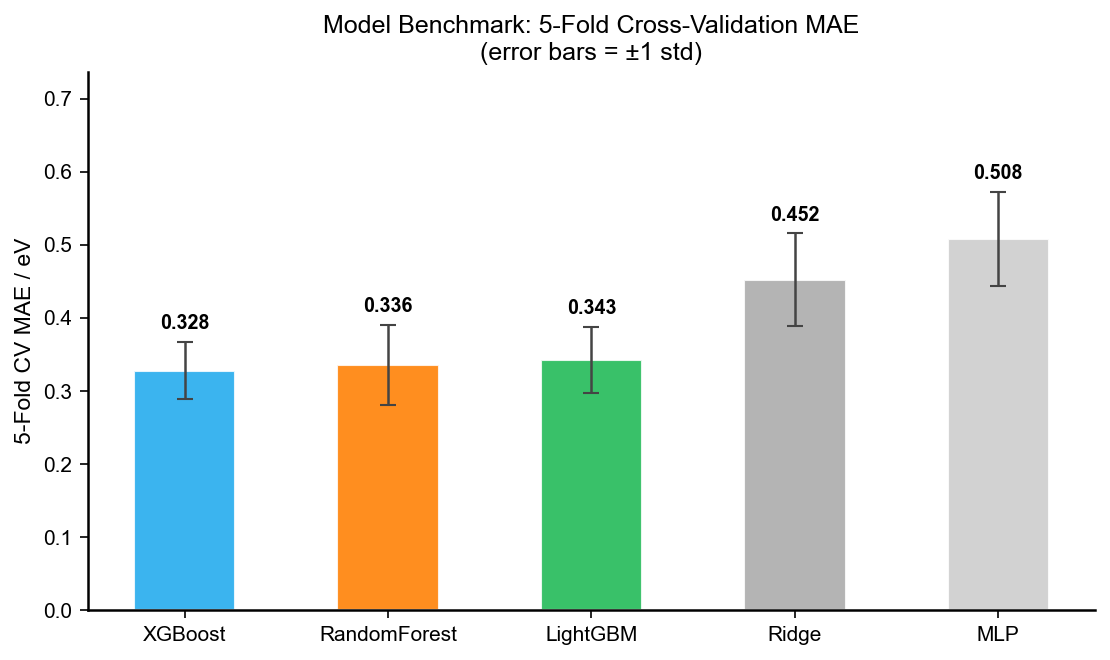

Saved: Table01_CV_results.csv
Cell 06 complete ✓


In [6]:
# Cell 06  5-Fold CV 基准测试（五模型）
print("=" * 60)
print("Cell 06: 5-Fold Cross-Validation Benchmark")
print("=" * 60)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline        import Pipeline
from sklearn.base            import clone

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("model", clone(model))])
    scores = cross_val_score(
        pipe, X, y,
        scoring="neg_mean_absolute_error",
        cv=kf, n_jobs=-1
    )
    mae_scores = -scores
    cv_rows.append({
        "Model":        name,
        "CV_MAE_mean":  round(mae_scores.mean(), 4),
        "CV_MAE_std":   round(mae_scores.std(),  4),
    })
    print(f"  {name:<14s}  {mae_scores.mean():.4f} ± {mae_scores.std():.4f} eV")

df_cv = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean").reset_index(drop=True)
print()
display(df_cv)

# ── CV MAE 条形图 ─────────────────────────────────────────────────────
df_plot = df_cv.sort_values("CV_MAE_mean")
colors  = [MODEL_COLORS.get(m, "#999999") for m in df_plot["Model"]]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(
    df_plot["Model"], df_plot["CV_MAE_mean"],
    yerr=df_plot["CV_MAE_std"],
    color=colors, alpha=0.88, edgecolor="white",
    width=0.5, capsize=4,
    error_kw={"linewidth": 1.2, "ecolor": COLOR_GRAY}
)
for bar, row in zip(bars, df_plot.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row.CV_MAE_std + 0.012,
        f"{row.CV_MAE_mean:.3f}",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold"
    )
ax.set_ylabel("5-Fold CV MAE / eV")
ax.set_title("Model Benchmark: 5-Fold Cross-Validation MAE\n(error bars = ±1 std)")
ax.set_ylim(0, df_plot["CV_MAE_mean"].max() * 1.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
save_fig("Fig01_CV_benchmark")
plt.show()

df_cv.to_csv(os.path.join(OUTDIR, "Table01_CV_results.csv"),
             index=False, encoding="utf-8-sig")
print("Saved: Table01_CV_results.csv")
print("Cell 06 complete ✓")


Cell 07 — 训练/测试集划分 + 全套模型训练

In [7]:
# Cell 07  训练/测试集划分 + 全套模型训练
print("=" * 60)
print("Cell 07: Train/Test Split + Model Training")
print("=" * 60)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train : " + str(len(X_train)) + " samples")
print("Test  : " + str(len(X_test))  + " samples")

fitted    = {}
test_rows = []

for name, model in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("model", clone(model))])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    y_pred = pipe.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = mean_squared_error(y_test, y_pred, squared=False)
    r2     = r2_score(y_test, y_pred)

    test_rows.append({
        "Model":        name,
        "Test_MAE_eV":  round(mae,  4),
        "Test_RMSE_eV": round(rmse, 4),
        "Test_R2":      round(r2,   4),
    })
    print(
        "  " + name.ljust(14) +
        "  MAE="  + str(round(mae,  4)) +
        "  RMSE=" + str(round(rmse, 4)) +
        "  R2="   + str(round(r2,   4))
    )

df_test = pd.DataFrame(test_rows).sort_values(
    "Test_MAE_eV"
).reset_index(drop=True)

print("")
display(df_test)

# 记录最优模型
best_name = df_test.iloc[0]["Model"]
best_pipe = fitted[best_name]
print("")
print("Best model : " + best_name)
print("Test MAE   : " + str(df_test.iloc[0]["Test_MAE_eV"]) + " eV")

df_test.to_csv(
    os.path.join(OUTDIR, "Table02_test_results.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Table02_test_results.csv")
print("Cell 07 complete")



Cell 07: Train/Test Split + Model Training
Train : 157 samples
Test  : 40 samples
  Ridge           MAE=0.3431  RMSE=0.4634  R2=0.9199
  RandomForest    MAE=0.2606  RMSE=0.438  R2=0.9285
  MLP             MAE=0.6557  RMSE=0.9293  R2=0.678
  XGBoost         MAE=0.3013  RMSE=0.5391  R2=0.8916


  File "D:\Anaconda\Anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
  File "D:\Anaconda\Anaconda3\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "D:\Anaconda\Anaconda3\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\Anaconda\Anaconda3\lib\subprocess.py", line 1420, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


  LightGBM        MAE=0.2801  RMSE=0.453  R2=0.9235



,Model,Test_MAE_eV,Test_RMSE_eV,Test_R2
0,RandomForest,0.2606,0.4380,0.9285
1,LightGBM,0.2801,0.4530,0.9235
2,XGBoost,0.3013,0.5391,0.8916
3,Ridge,0.3431,0.4634,0.9199
4,MLP,0.6557,0.9293,0.6780



Best model : RandomForest
Test MAE   : 0.2606 eV
Saved: Table02_test_results.csv
Cell 07 complete


Cell 08 — 奇偶图 + 残差分布图

Cell 08: Parity Plots + Residual Distributions
  Saved: Fig02_parity_residual_all.png / .tiff


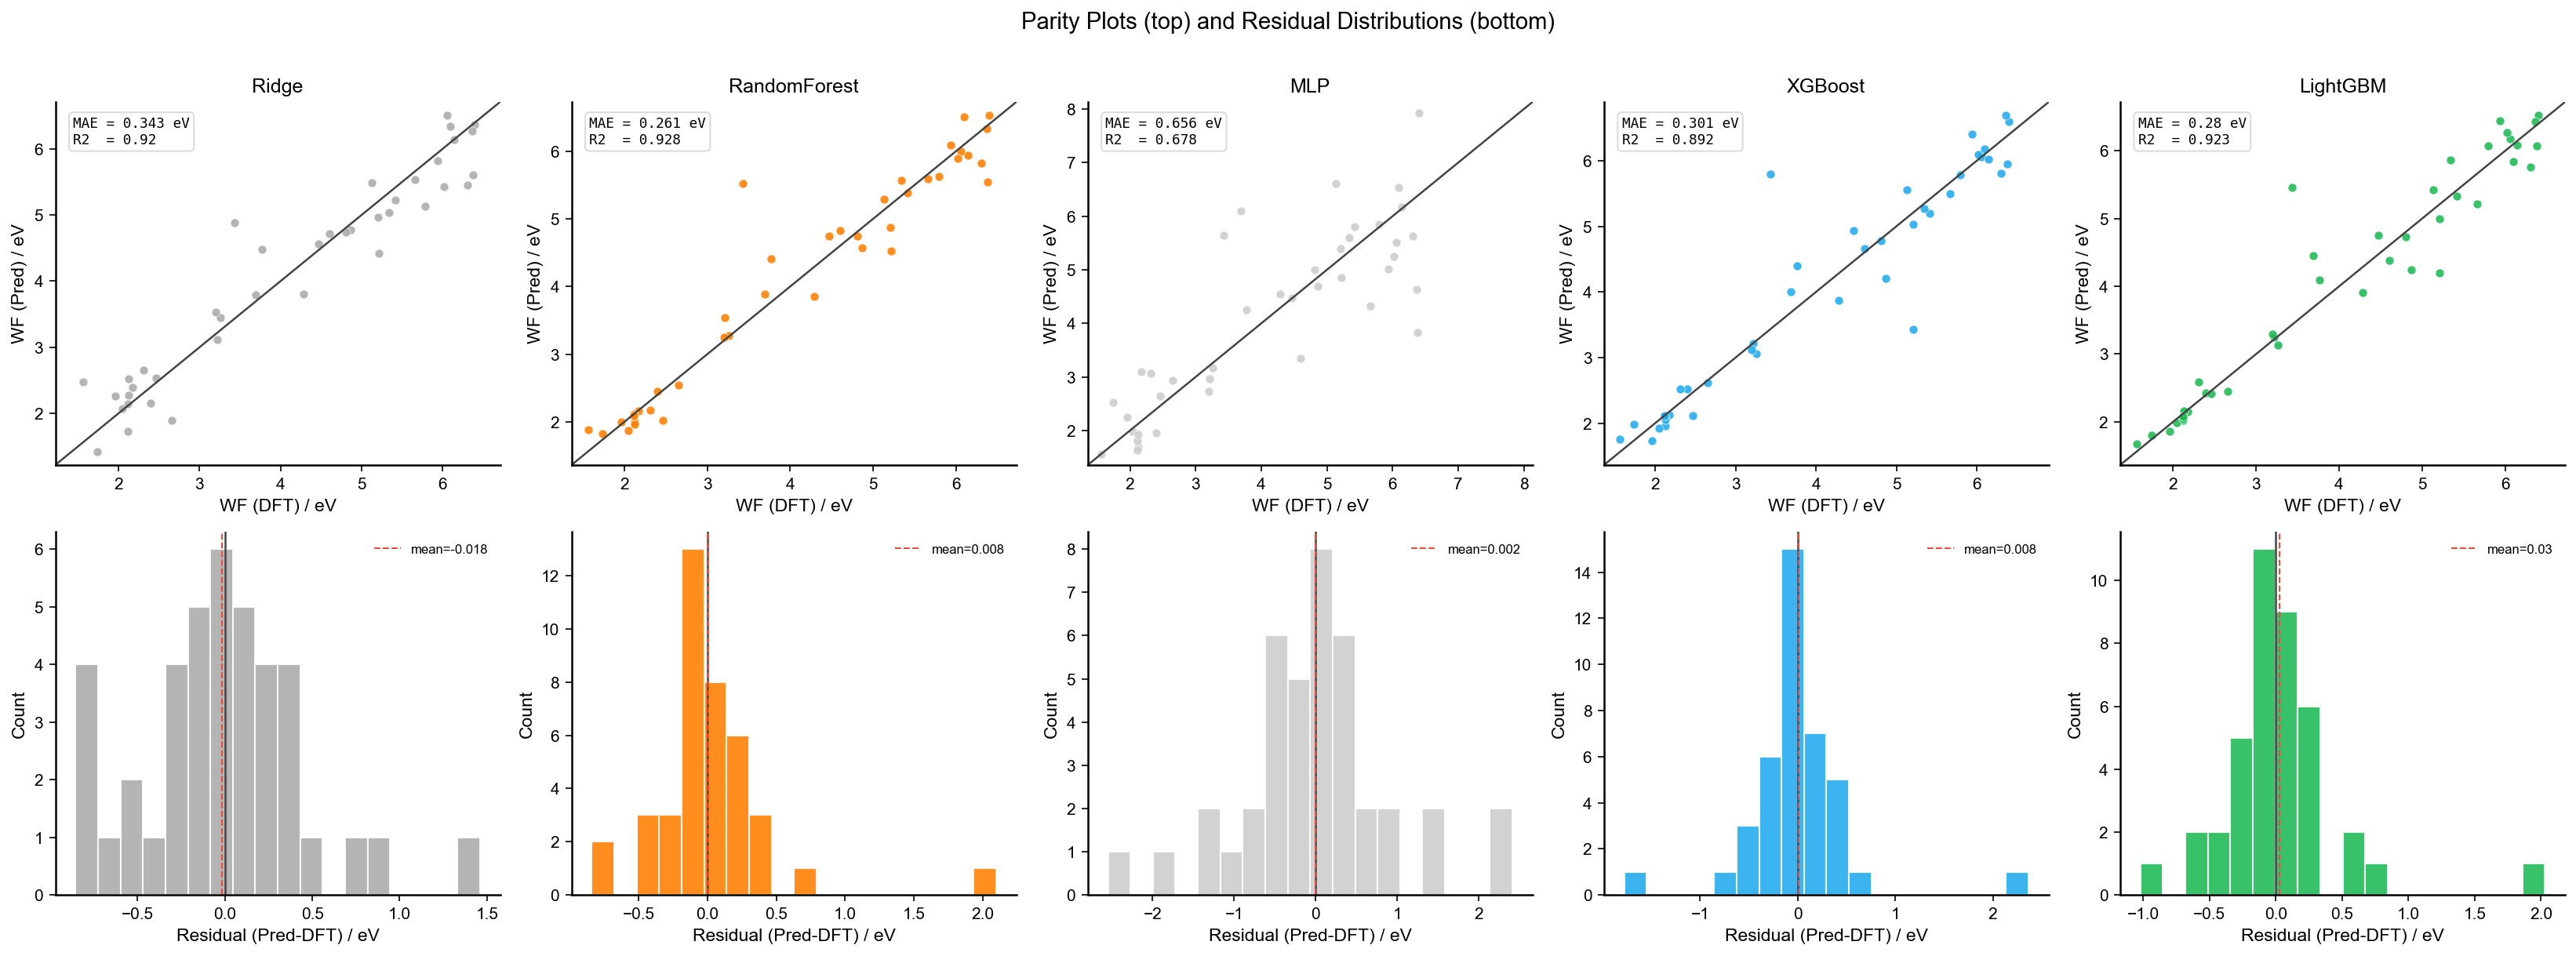

Saved: SI_parity_data_*.csv  (5 files)
Cell 08 complete


In [8]:
# Cell 08  奇偶图 + 残差分布图（五模型）
print("=" * 60)
print("Cell 08: Parity Plots + Residual Distributions")
print("=" * 60)

from sklearn.metrics import mean_absolute_error, r2_score

model_order = ["Ridge", "RandomForest", "MLP", "XGBoost", "LightGBM"]
fig, axes   = plt.subplots(2, 5, figsize=(22, 8))

parity_data = []

for col_idx, name in enumerate(model_order):
    pipe   = fitted[name]
    y_pred = pipe.predict(X_test)
    color  = MODEL_COLORS.get(name, COLOR_GRAY)
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    res    = y_pred - y_test

    # ── 奇偶图 ───────────────────────────────────────────────────────
    ax_p = axes[0, col_idx]
    ax_p.scatter(
        y_test, y_pred,
        s=28, alpha=0.88,
        color=color,
        edgecolor="white", linewidth=0.35
    )
    lo = float(min(y_test.min(), y_pred.min())) - 0.2
    hi = float(max(y_test.max(), y_pred.max())) + 0.2
    ax_p.plot([lo, hi], [lo, hi], color=COLOR_GRAY, linewidth=1.2)
    ax_p.set_xlim(lo, hi)
    ax_p.set_ylim(lo, hi)
    ax_p.set_xlabel("WF (DFT) / eV")
    ax_p.set_ylabel("WF (Pred) / eV")
    ax_p.set_title(name)

    # 统计信息文本（不用 f-string 换行）
    info_line1 = "MAE = " + str(round(mae, 3)) + " eV"
    info_line2 = "R2  = " + str(round(r2,  3))
    info_text  = info_line1 + "\n" + info_line2
    ax_p.text(
        0.04, 0.96, info_text,
        transform=ax_p.transAxes,
        va="top", ha="left",
        fontsize=8.5,
        fontfamily="monospace",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.8
        )
    )
    ax_p.spines["top"].set_visible(False)
    ax_p.spines["right"].set_visible(False)

    # ── 残差图 ───────────────────────────────────────────────────────
    ax_r = axes[1, col_idx]
    ax_r.hist(res, bins=18, color=color, alpha=0.88, edgecolor="white")
    ax_r.axvline(0, color=COLOR_GRAY, linewidth=1.2)
    ax_r.axvline(
        res.mean(),
        color=COLOR_RED, linewidth=1.0, linestyle="--",
        label="mean=" + str(round(float(res.mean()), 3))
    )
    ax_r.set_xlabel("Residual (Pred-DFT) / eV")
    ax_r.set_ylabel("Count")
    ax_r.legend(frameon=False, fontsize=8)
    ax_r.spines["top"].set_visible(False)
    ax_r.spines["right"].set_visible(False)

    # 收集数据
    parity_data.append({
        "Model":     name,
        "WF_DFT":    list(y_test),
        "WF_Pred":   list(y_pred),
        "Residual":  list(res),
    })

plt.suptitle(
    "Parity Plots (top) and Residual Distributions (bottom)",
    fontsize=14, y=1.01
)
save_fig("Fig02_parity_residual_all")
plt.show()

# ── 导出奇偶图原始数据 ────────────────────────────────────────────────
for d in parity_data:
    name = d["Model"]
    pd.DataFrame({
        "WF_DFT_eV":   d["WF_DFT"],
        "WF_Pred_eV":  d["WF_Pred"],
        "Residual_eV": d["Residual"],
    }).to_csv(
        os.path.join(OUTDIR, "SI_parity_data_" + name + ".csv"),
        index=False, encoding="utf-8-sig"
    )
print("Saved: SI_parity_data_*.csv  (5 files)")
print("Cell 08 complete")


Cell 09 — Bootstrap 不确定度分析

✓ feature_cols 验证通过，共 22 列
  CAT (3): ['M_label', 'X_label', 'T_label']
  NUM (19): ['n', 'a', 'd', 'VBM_PBE', 'CBM_PBE', 'Eg_PBE', 'VBM_PBE0', 'CBM_PBE0', 'Eg_PBE0', 'IsGap', 'En_M', 'En_X', 'En_T', 'r_M', 'r_X', 'r_T', 'Ip_M', 'Ip_X', 'Ip_T']
X_train : (157, 22)  type=DataFrame
X_test  : (40, 22)   type=DataFrame
y_train : (157,)
y_test  : (40,)
------------------------------------------------------------
  Bootstrapping RandomForest  (200 iters)... MAE = 0.3414 ± 0.0503  95%CI [0.2690, 0.4560]
  Bootstrapping XGBoost  (200 iters)... MAE = 0.3377 ± 0.0485  95%CI [0.2618, 0.4454]
  Bootstrapping LightGBM  (200 iters)... MAE = 0.3323 ± 0.0480  95%CI [0.2604, 0.4409]
  Saved: Fig03_bootstrap_uncertainty.png / .tiff


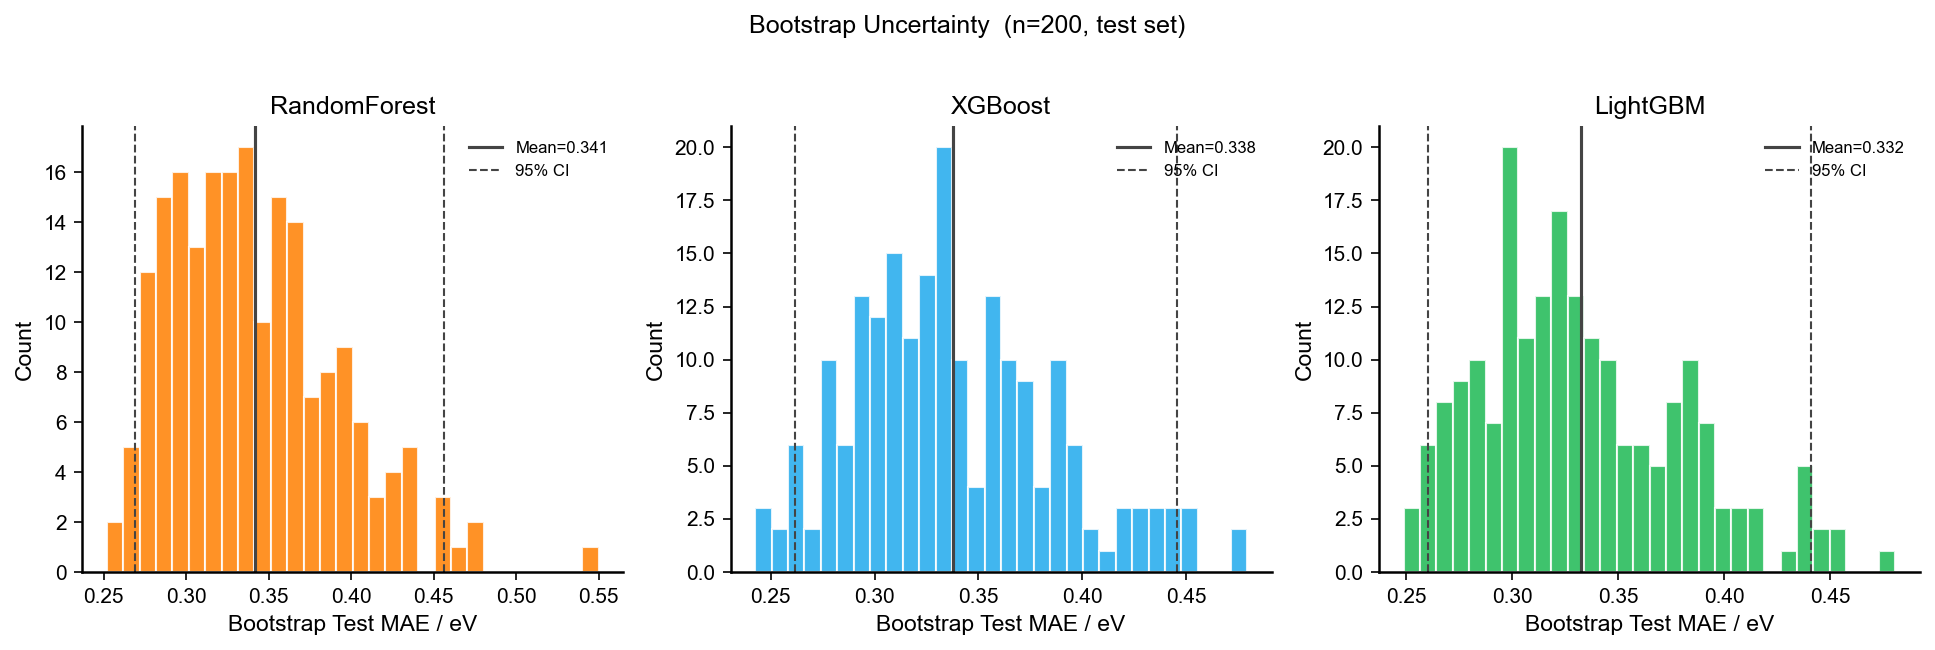

,Model,MAE_mean_eV,MAE_std_eV,MAE_CI95_lo,MAE_CI95_hi
0,RandomForest,0.3414,0.0503,0.2690,0.4560
1,XGBoost,0.3377,0.0485,0.2618,0.4454
2,LightGBM,0.3323,0.0480,0.2604,0.4409


Saved: Table03_bootstrap_UQ.csv
Saved: SI_bootstrap_raw.csv
Saved: Table03_bootstrap_UQ_Origin.csv
Saved: SI_bootstrap_hist_RandomForest.csv
Saved: SI_bootstrap_hist_XGBoost.csv
Saved: SI_bootstrap_hist_LightGBM.csv
Saved: SI_bootstrap_reflines.csv
---------------------------------------------
Origin 导出完毕，共 6 个 CSV：
  ① SI_bootstrap_raw.csv
  ② Table03_bootstrap_UQ_Origin.csv
  ③ SI_bootstrap_hist_RandomForest.csv
  ④ SI_bootstrap_hist_XGBoost.csv
  ⑤ SI_bootstrap_hist_LightGBM.csv
  ⑥ SI_bootstrap_reflines.csv
---------------------------------------------
Cell 09 complete ✓


In [9]:
# Cell 09  Bootstrap 不确定度分析
# ============================================================
# ── 1. 数据划分（列名与 preprocess 精确对齐）────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils import resample


# 与 preprocess 的 ColumnTransformer 完全一致
CAT_COLS = ["M_label", "X_label", "T_label"]
NUM_COLS = ["n", "a", "d",
            "VBM_PBE", "CBM_PBE", "Eg_PBE",
            "VBM_PBE0", "CBM_PBE0", "Eg_PBE0",
            "IsGap",
            "En_M", "En_X", "En_T",
            "r_M",  "r_X",  "r_T",
            "Ip_M", "Ip_X", "Ip_T"]

feature_cols = CAT_COLS + NUM_COLS   # 共 22 列

# 验证列完整性
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"df 中缺少以下列，请检查数据预处理步骤: {missing}")
else:
    print(f"✓ feature_cols 验证通过，共 {len(feature_cols)} 列")
    print(f"  CAT ({len(CAT_COLS)}): {CAT_COLS}")
    print(f"  NUM ({len(NUM_COLS)}): {NUM_COLS}")

X = df[feature_cols]       # DataFrame，保留列名供 ColumnTransformer 使用
y = df[COL_Y].values       # numpy

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"X_train : {X_train.shape}  type={type(X_train).__name__}")
print(f"X_test  : {X_test.shape}   type={type(X_test).__name__}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print("-" * 60)


# ── 2. Bootstrap 循环 ─────────────────────────────────────────────────
N_BOOTSTRAP = 200
UQ_MODELS   = ["RandomForest", "XGBoost", "LightGBM"]
uq_results  = {}

for name in UQ_MODELS:
    print(f"  Bootstrapping {name}  ({N_BOOTSTRAP} iters)...", end=" ")
    mae_list = []

    for i in range(N_BOOTSTRAP):
        # resample 对 DataFrame 输入会自动保留列名
        X_bs, y_bs = resample(X_train, y_train, random_state=i)

        pipe_bs = Pipeline([
            ("prep",  clone(preprocess)),
            ("model", clone(models[name]))
        ])
        pipe_bs.fit(X_bs, y_bs)
        mae_list.append(mean_absolute_error(y_test, pipe_bs.predict(X_test)))

    uq_results[name] = {
        "mean":  np.mean(mae_list),
        "std":   np.std(mae_list),
        "ci_lo": np.percentile(mae_list, 2.5),
        "ci_hi": np.percentile(mae_list, 97.5),
        "dist":  mae_list,
    }

    r = uq_results[name]
    print(f"MAE = {r['mean']:.4f} ± {r['std']:.4f}  "
          f"95%CI [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]")

# ── 3. Bootstrap 分布图 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, name in zip(axes, UQ_MODELS):
    r = uq_results[name]

    ax.hist(r["dist"], bins=30,
            color=MODEL_COLORS[name], alpha=0.85, edgecolor="white")
    ax.axvline(r["mean"],  color=COLOR_GRAY, lw=1.5,
               label=f"Mean={r['mean']:.3f}")
    ax.axvline(r["ci_lo"], color=COLOR_GRAY, lw=1.0,
               linestyle="--", label="95% CI")
    ax.axvline(r["ci_hi"], color=COLOR_GRAY, lw=1.0, linestyle="--")

    ax.set_xlabel("Bootstrap Test MAE / eV")
    ax.set_ylabel("Count")
    ax.set_title(name)
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"Bootstrap Uncertainty  (n={N_BOOTSTRAP}, test set)",
             fontsize=12, y=1.02)
save_fig("Fig03_bootstrap_uncertainty")
plt.show()

# ── 4. 保存 UQ 汇总表 ─────────────────────────────────────────────────
uq_rows = [{
    "Model":       name,
    "MAE_mean_eV": round(uq_results[name]["mean"],  4),
    "MAE_std_eV":  round(uq_results[name]["std"],   4),
    "MAE_CI95_lo": round(uq_results[name]["ci_lo"], 4),
    "MAE_CI95_hi": round(uq_results[name]["ci_hi"], 4),
} for name in UQ_MODELS]

df_uq = pd.DataFrame(uq_rows)
display(df_uq)
df_uq.to_csv(os.path.join(OUTDIR, "Table03_bootstrap_UQ.csv"),
             index=False, encoding="utf-8-sig")
print("Saved: Table03_bootstrap_UQ.csv")

# ── 5. Origin 导出 ────────────────────────────────────────────────────

# ① 原始 Bootstrap 分布（200行 × 3列）
pd.DataFrame({
    f"{m}_MAE_eV": uq_results[m]["dist"] for m in UQ_MODELS
}).to_csv(
    os.path.join(OUTDIR, "SI_bootstrap_raw.csv"),
    index_label="Bootstrap_Iteration",
    encoding="utf-8-sig"
)
print("Saved: SI_bootstrap_raw.csv")

# ② 汇总统计（追加 CI 宽度列）
df_uq_export = df_uq.copy()
df_uq_export["MAE_CI95_width"] = (
    df_uq_export["MAE_CI95_hi"] - df_uq_export["MAE_CI95_lo"]
).round(4)
df_uq_export.to_csv(
    os.path.join(OUTDIR, "Table03_bootstrap_UQ_Origin.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Table03_bootstrap_UQ_Origin.csv")

# ③ 直方图分箱数据（每模型一个文件，30 bins）
for name in UQ_MODELS:
    dist = np.array(uq_results[name]["dist"])
    counts, edges = np.histogram(dist, bins=30)
    pd.DataFrame({
        "BinCenter_eV": np.round(0.5 * (edges[:-1] + edges[1:]), 5),
        "Count":        counts,
        "BinWidth_eV":  np.round(np.full(30, edges[1] - edges[0]), 5),
    }).to_csv(
        os.path.join(OUTDIR, f"SI_bootstrap_hist_{name}.csv"),
        index=False, encoding="utf-8-sig"
    )
    print(f"Saved: SI_bootstrap_hist_{name}.csv")

# ④ 参考线位置（均值线 + 95% CI 虚线）
ref_rows = []
for name in UQ_MODELS:
    r = uq_results[name]
    for line_type, pos in [("Mean",    r["mean"]),
                            ("CI95_Lo", r["ci_lo"]),
                            ("CI95_Hi", r["ci_hi"])]:
        ref_rows.append({
            "Model":         name,
            "Line_Type":     line_type,
            "Position_eV":   round(pos, 4),
            "Color_Hex":     MODEL_COLORS[name] if line_type == "Mean" else "#666666",
            "Line_Style":    "Solid" if line_type == "Mean" else "Dash",
            "Line_Width_pt": 1.5    if line_type == "Mean" else 1.0,
        })
pd.DataFrame(ref_rows).to_csv(
    os.path.join(OUTDIR, "SI_bootstrap_reflines.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: SI_bootstrap_reflines.csv")

print("-" * 45)
print("Origin 导出完毕，共 6 个 CSV：")
print("  ① SI_bootstrap_raw.csv")
print("  ② Table03_bootstrap_UQ_Origin.csv")
print("  ③ SI_bootstrap_hist_RandomForest.csv")
print("  ④ SI_bootstrap_hist_XGBoost.csv")
print("  ⑤ SI_bootstrap_hist_LightGBM.csv")
print("  ⑥ SI_bootstrap_reflines.csv")
print("-" * 45)
print("Cell 09 complete ✓")


Cell 10 — SHAP 全局特征重要性

Cell 10: SHAP Global Feature Importance (all 197 samples)
SHAP model : XGBoost
SHAP input shape : (197, 35)  (all 197 samples)
shap_vals shape  : (197, 35)
Top-7 features (excluding categorical labels):


,feature,mean_abs_shap
0,En_T,0.199601
1,En_M,0.156066
2,VBM_PBE0,0.125089
3,a,0.116617
4,r_M,0.099434
5,CBM_PBE0,0.092166
6,d,0.088729


  Saved: Fig04_SHAP_global_bar.png / .tiff


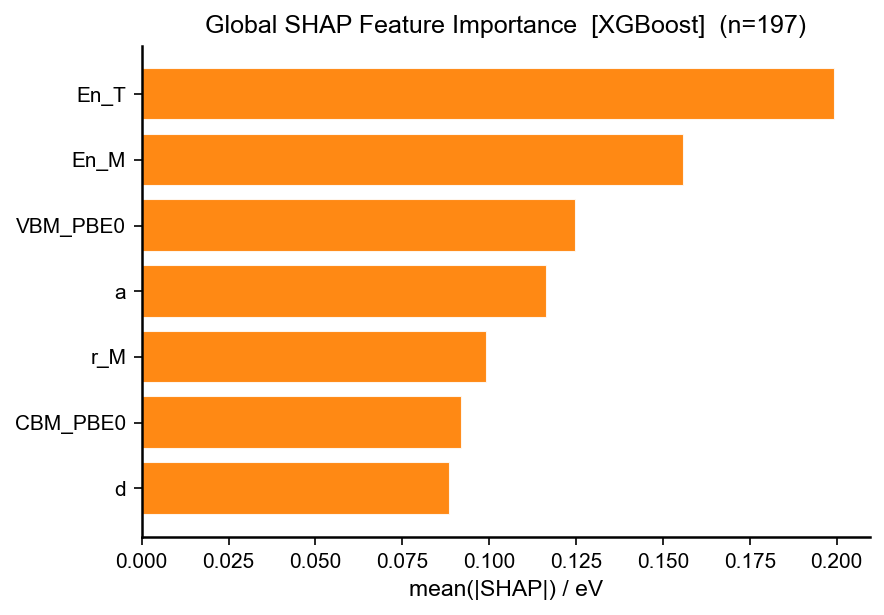

  Saved: Fig05_SHAP_beeswarm.png / .tiff


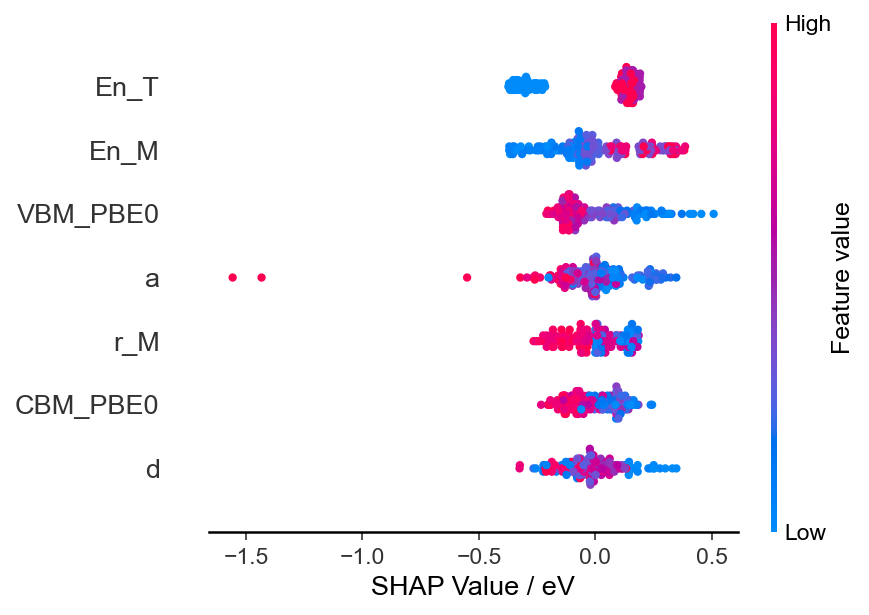

Saved: Table04_SHAP_all_features.csv
Saved: Table05_SHAP_top7.csv
Cell 10 complete ✓


In [22]:
# Cell 10  SHAP 全局特征重要性分析（基于全部197个样本）
print("=" * 60)
print("Cell 10: SHAP Global Feature Importance (all 197 samples)")
print("=" * 60)

import shap
import numpy as np

TOPK = 7

# ── 获取最优树模型（优先 XGBoost，其次 RF）────────────────────────────
if "XGBoost" in fitted:
    shap_model_name = "XGBoost"
elif "LightGBM" in fitted:
    shap_model_name = "LightGBM"
else:
    shap_model_name = "RandomForest"

print("SHAP model : " + shap_model_name)

shap_pipe  = fitted[shap_model_name]
prep_shap  = shap_pipe.named_steps["prep"]
model_shap = shap_pipe.named_steps["model"]

# ── 转换全部197个样本 ─────────────────────────────────────────────────
X_all_trans = prep_shap.transform(X)
try:
    X_all_trans = X_all_trans.toarray()
except Exception:
    pass

print(f"SHAP input shape : {X_all_trans.shape}  (all {len(X)} samples)")

# ── 获取编码后特征名 ──────────────────────────────────────────────────
ohe_shap   = prep_shap.named_transformers_["cat"]
feat_names = list(ohe_shap.get_feature_names_out(cat_cols)) + list(num_cols)
n_ohe      = sum(len(c) for c in ohe_shap.categories_)

# ── SHAP 值计算（全样本）─────────────────────────────────────────────
explainer = shap.TreeExplainer(model_shap)
shap_vals = explainer.shap_values(X_all_trans)

print(f"shap_vals shape  : {shap_vals.shape}")

# ── 聚合：one-hot → 原始列 ────────────────────────────────────────────
mean_abs_encoded = np.abs(shap_vals).mean(axis=0)
group_rows = []
start = 0
for col, sz in zip(cat_cols, [len(c) for c in ohe_shap.categories_]):
    group_rows.append([col, float(mean_abs_encoded[start:start+sz].sum())])
    start += sz
for j, col in enumerate(num_cols):
    group_rows.append([col, float(mean_abs_encoded[n_ohe + j])])

df_shap_all = pd.DataFrame(
    group_rows, columns=["feature", "mean_abs_shap"]
).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# 排除标签列，取 Top-K
EXCLUDE_LABELS = {"M_label", "X_label", "T_label"}
df_shap_topk = df_shap_all[
    ~df_shap_all["feature"].isin(EXCLUDE_LABELS)
].head(TOPK).copy().reset_index(drop=True)

print("Top-" + str(TOPK) + " features (excluding categorical labels):")
display(df_shap_topk)

# ── SHAP 条形图 ───────────────────────────────────────────────────────
df_bar = df_shap_topk.iloc[::-1]
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.barh(
    df_bar["feature"], df_bar["mean_abs_shap"],
    color=COLOR_ORANGE, alpha=0.92, edgecolor="white"
)
ax.set_xlabel("mean(|SHAP|) / eV")
ax.set_title("Global SHAP Feature Importance  [" + shap_model_name +
             "]  (n=197)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
save_fig("Fig04_SHAP_global_bar")
plt.show()

# ── SHAP Beeswarm（仅数值特征 Top-K）────────────────────────────────
topk_num_feats = [f for f in df_shap_topk["feature"] if f in num_cols]
topk_num_idx   = [num_cols.index(f) for f in topk_num_feats]

shap_num_sub = shap_vals[:, [n_ohe + i for i in topk_num_idx]]
X_num_sub    = X_all_trans[:, [n_ohe + i for i in topk_num_idx]]

plt.figure(figsize=(6, 4.2))
shap.summary_plot(
    shap_num_sub, X_num_sub,
    feature_names=topk_num_feats,
    show=False, max_display=TOPK,
    plot_size=None
)
ax_bs = plt.gca()
ax_bs.set_title("")
ax_bs.set_xlabel("SHAP Value / eV")
for line in list(ax_bs.lines):
    xd = np.array(line.get_xdata(), dtype=float)
    if line.get_linestyle() in ["--", ":", "-."] or (
        xd.size >= 2 and np.allclose(xd, 0.0)
    ):
        try:
            line.remove()
        except Exception:
            pass
plt.tight_layout()
save_fig("Fig05_SHAP_beeswarm")
plt.show()

# ── 保存 ─────────────────────────────────────────────────────────────
df_shap_all.to_csv(
    os.path.join(OUTDIR, "Table04_SHAP_all_features.csv"),
    index=False, encoding="utf-8-sig"
)
df_shap_topk.to_csv(
    os.path.join(OUTDIR, "Table05_SHAP_top" + str(TOPK) + ".csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Table04_SHAP_all_features.csv")
print("Saved: Table05_SHAP_top" + str(TOPK) + ".csv")
print("Cell 10 complete ✓")


Cell 11 — 描述符共线性 + VIF 分析

Cell 11: Descriptor Collinearity + VIF Analysis
  Saved: Fig06_correlation_matrix.png / .tiff


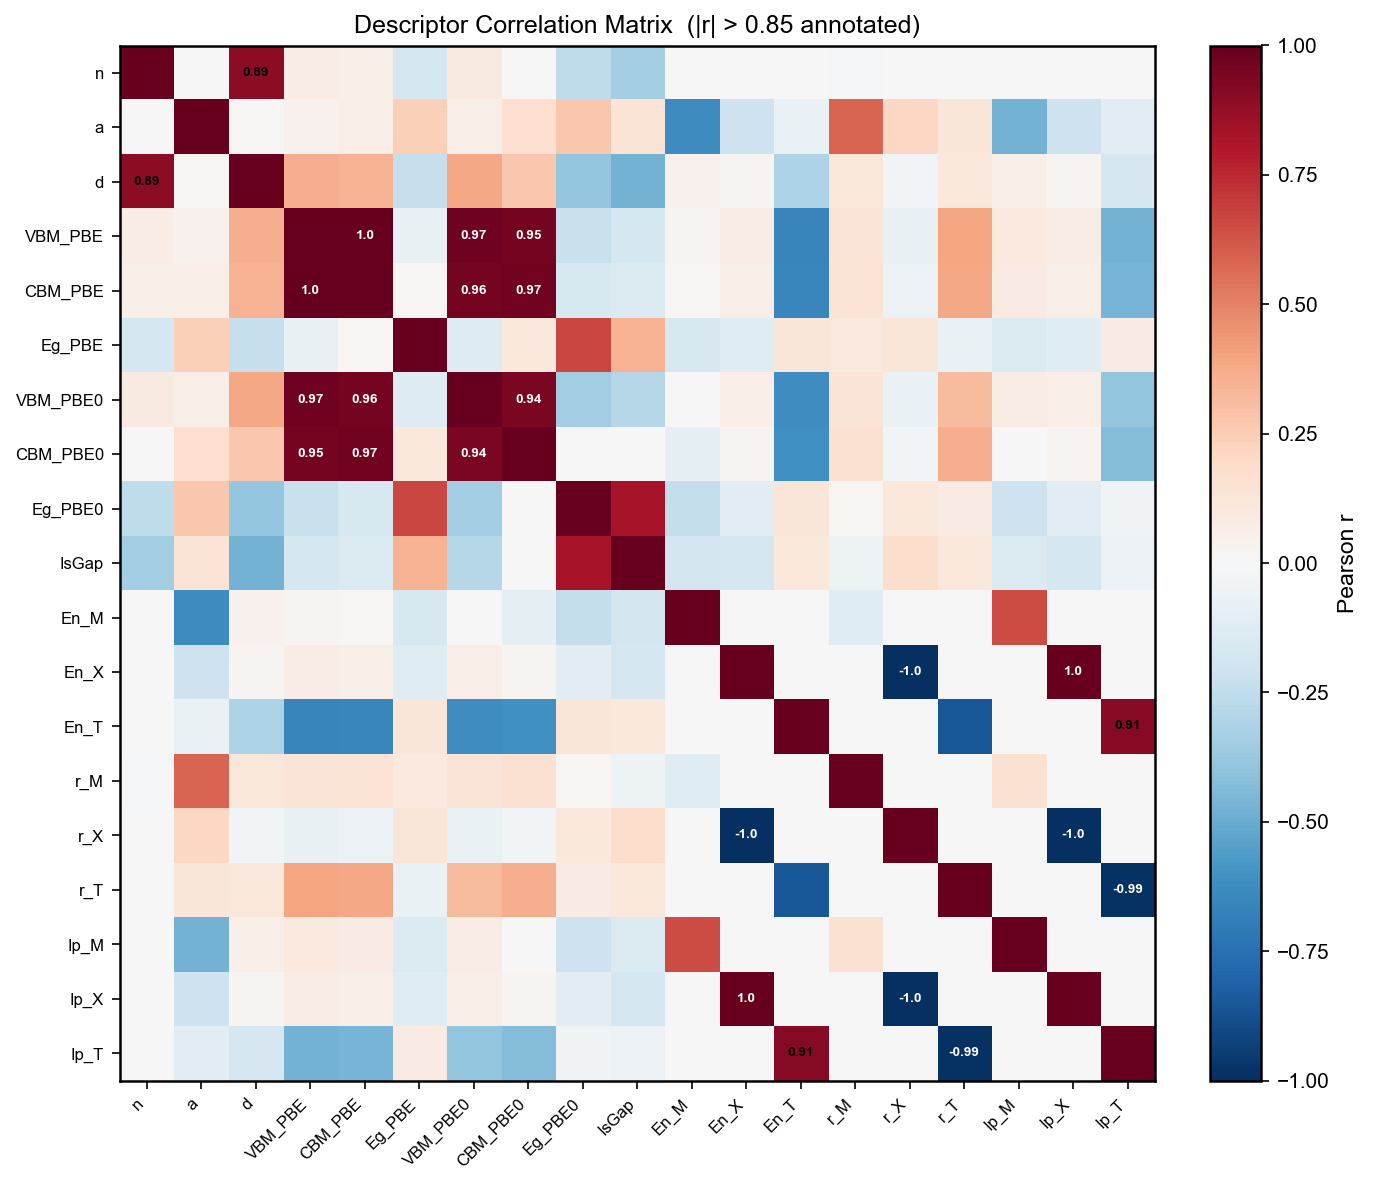

VIF results  (>10 = high collinearity,  >5 = moderate):


,Feature,VIF
14,r_X,inf
11,En_X,inf
18,Ip_T,2354310.21
7,CBM_PBE0,1436772.54
5,Eg_PBE,319718.28
15,r_T,91414.02
12,En_T,56980.69
17,Ip_X,51875.83
3,VBM_PBE,30697.32
8,Eg_PBE0,21128.16


  Saved: Fig07_VIF.png / .tiff


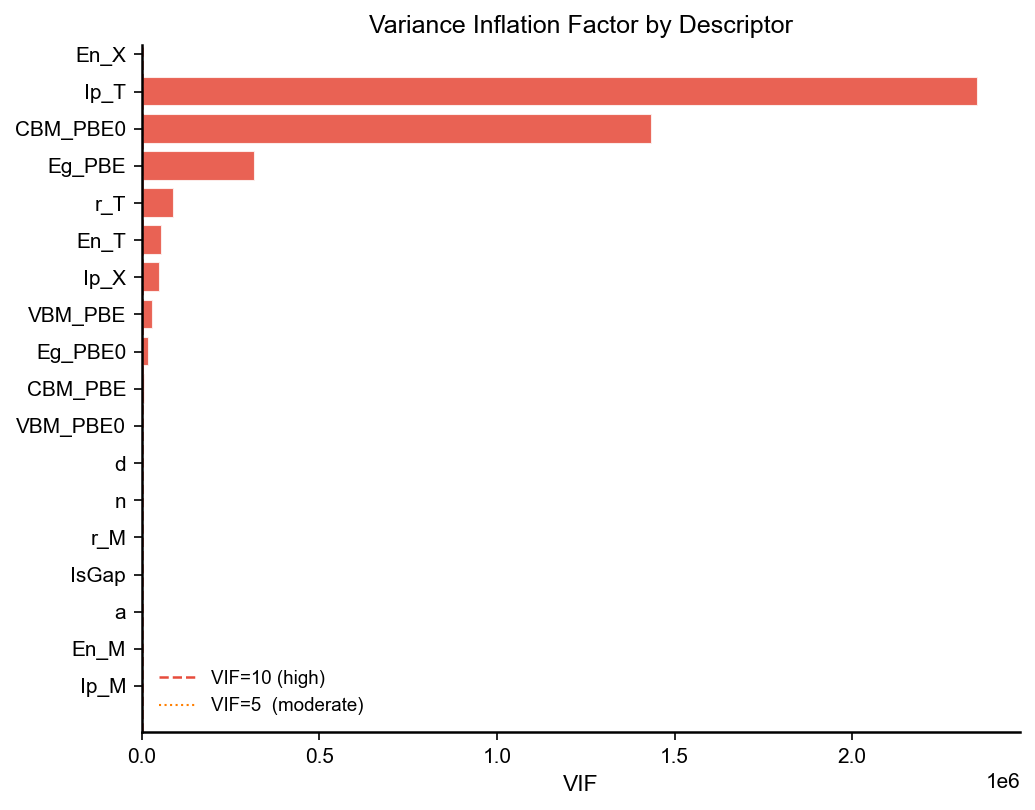

Saved: Table06_VIF.csv
Cell 11 complete


In [11]:
# Cell 11  描述符共线性矩阵 + VIF 分析
print("=" * 60)
print("Cell 11: Descriptor Collinearity + VIF Analysis")
print("=" * 60)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# ── 相关性热图 ────────────────────────────────────────────────────────
df_num_only = df[num_cols].copy().astype(float)
corr_matrix = df_num_only.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr_matrix.values[i, j]
        if i != j and abs(val) > 0.85:
            txt_color = "white" if abs(val) > 0.92 else "black"
            ax.text(
                j, i, str(round(val, 2)),
                ha="center", va="center",
                fontsize=6.5, fontweight="bold",
                color=txt_color
            )

ax.set_title("Descriptor Correlation Matrix  (|r| > 0.85 annotated)")
plt.tight_layout()
save_fig("Fig06_correlation_matrix")
plt.show()

# ── VIF 计算 ──────────────────────────────────────────────────────────
X_scaled = StandardScaler().fit_transform(
    df_num_only.fillna(df_num_only.median())
)
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

vif_rows = []
for i, col in enumerate(num_cols):
    try:
        vif = variance_inflation_factor(X_scaled_df.values, i)
    except Exception:
        vif = float("nan")
    vif_rows.append({"Feature": col, "VIF": round(float(vif), 2)})

df_vif = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
print("VIF results  (>10 = high collinearity,  >5 = moderate):")
display(df_vif)

# ── VIF 条形图 ────────────────────────────────────────────────────────
df_vif_plot = df_vif.iloc[::-1]
bar_colors_vif = []
for v in df_vif_plot["VIF"]:
    if v > 10:
        bar_colors_vif.append(COLOR_RED)
    elif v > 5:
        bar_colors_vif.append(COLOR_ORANGE)
    else:
        bar_colors_vif.append(COLOR_BLUE)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(
    df_vif_plot["Feature"], df_vif_plot["VIF"],
    color=bar_colors_vif, alpha=0.88, edgecolor="white"
)
ax.axvline(10, color=COLOR_RED,    lw=1.2, linestyle="--",
           label="VIF=10 (high)")
ax.axvline(5,  color=COLOR_ORANGE, lw=1.0, linestyle=":",
           label="VIF=5  (moderate)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor by Descriptor")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig("Fig07_VIF")
plt.show()

df_vif.to_csv(
    os.path.join(OUTDIR, "Table06_VIF.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Table06_VIF.csv")
print("Cell 11 complete")


Cell 12 — LOMO 泛化误差测试

Cell 12: Leave-One-Metal-Out (LOMO) Generalization Test
Metals : ['Cr', 'Hf', 'Mo', 'Nb', 'Sc', 'Ta', 'Ti', 'V', 'W', 'Y', 'Zr']

  Cr    n_test=18   RandomForest=0.4944  XGBoost=0.5527  LightGBM=0.5153
  Hf    n_test=18   RandomForest=0.4234  XGBoost=0.3774  LightGBM=0.2918
  Mo    n_test=18   RandomForest=0.4615  XGBoost=0.4232  LightGBM=0.5213
  Nb    n_test=18   RandomForest=0.4429  XGBoost=0.2917  LightGBM=0.2396
  Sc    n_test=18   RandomForest=0.6332  XGBoost=0.6763  LightGBM=0.5756
  Ta    n_test=18   RandomForest=0.269  XGBoost=0.3068  LightGBM=0.2609
  Ti    n_test=18   RandomForest=0.1787  XGBoost=0.2264  LightGBM=0.1763
  V     n_test=17   RandomForest=0.2932  XGBoost=0.3296  LightGBM=0.3161
  W     n_test=18   RandomForest=0.3996  XGBoost=0.4058  LightGBM=0.3936
  Y     n_test=18   RandomForest=0.5685  XGBoost=0.6548  LightGBM=0.5646
  Zr    n_test=18   RandomForest=0.3487  XGBoost=0.2843  LightGBM=0.192



,Metal,N_test,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,Cr,18,0.4944,0.5527,0.5153
1,Hf,18,0.4234,0.3774,0.2918
2,Mo,18,0.4615,0.4232,0.5213
3,Nb,18,0.4429,0.2917,0.2396
4,Sc,18,0.6332,0.6763,0.5756
5,Ta,18,0.2690,0.3068,0.2609
6,Ti,18,0.1787,0.2264,0.1763
7,V,17,0.2932,0.3296,0.3161
8,W,18,0.3996,0.4058,0.3936
9,Y,18,0.5685,0.6548,0.5646


  Saved: Fig08_LOMO_generalization.png / .tiff


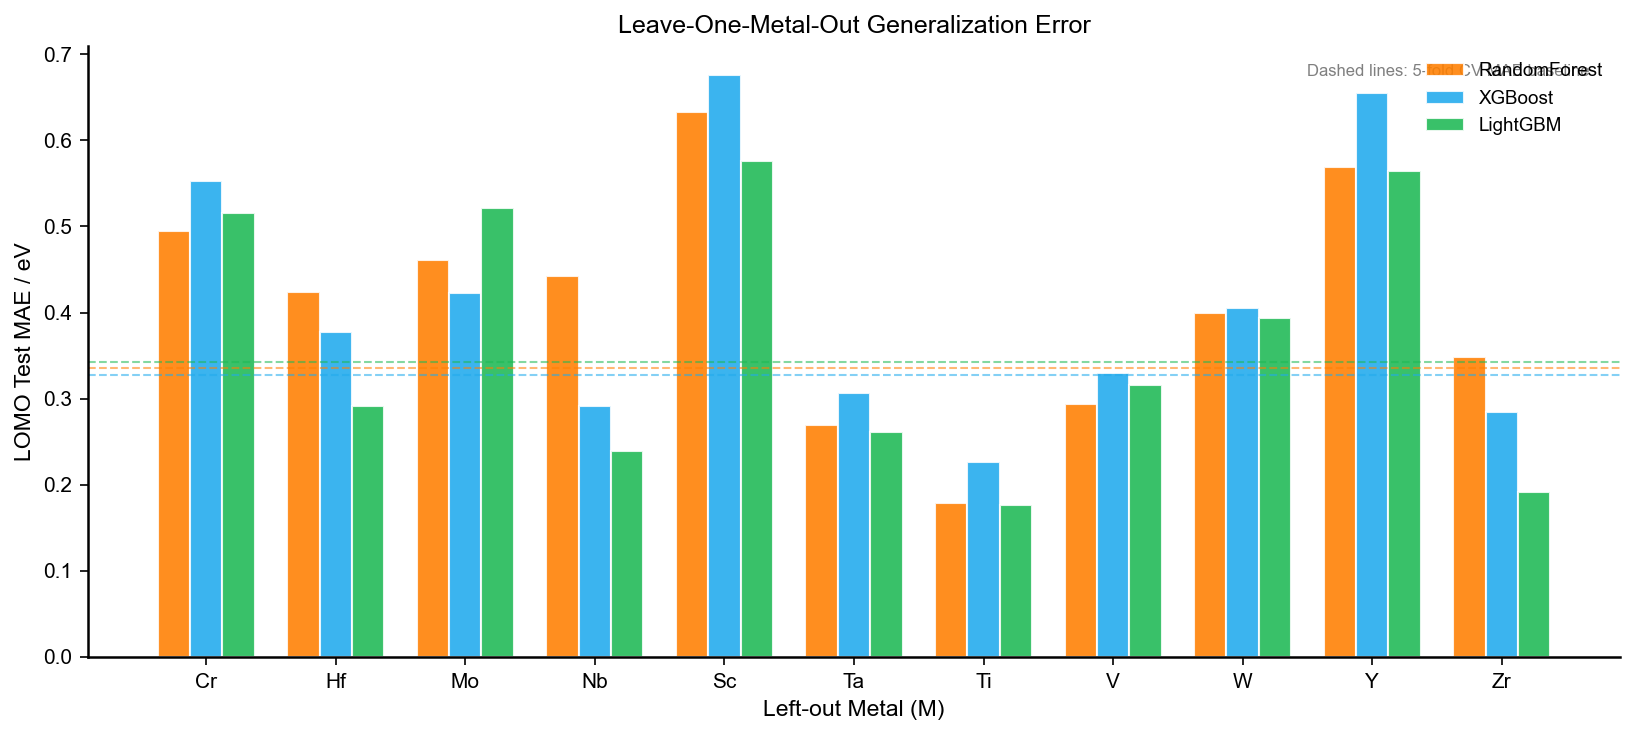

Saved: Table07_LOMO_error.csv
Cell 12 complete


In [12]:
# Cell 12  LOMO — Leave-One-Metal-Out 泛化误差测试
print("=" * 60)
print("Cell 12: Leave-One-Metal-Out (LOMO) Generalization Test")
print("=" * 60)

from sklearn.base import clone

LOMO_MODELS   = ["RandomForest", "XGBoost", "LightGBM"]
unique_metals = sorted(df[COL_M].unique())
print("Metals : " + str(unique_metals))
print("")

lomo_rows = []

for metal in unique_metals:
    mask_test  = (df[COL_M] == metal).values
    mask_train = ~mask_test

    X_lo_train = X[mask_train]
    y_lo_train = y[mask_train]
    X_lo_test  = X[mask_test]
    y_lo_test  = y[mask_test]

    row = {"Metal": metal, "N_test": int(mask_test.sum())}

    for name in LOMO_MODELS:
        pipe_lo = Pipeline([
            ("prep",  clone(preprocess)),
            ("model", clone(models[name]))
        ])
        pipe_lo.fit(X_lo_train, y_lo_train)
        mae_lo = mean_absolute_error(y_lo_test, pipe_lo.predict(X_lo_test))
        row["MAE_" + name] = round(mae_lo, 4)

    lomo_rows.append(row)
    line = "  " + metal.ljust(4) + "  n_test=" + str(row["N_test"]).ljust(3)
    for name in LOMO_MODELS:
        line += "  " + name + "=" + str(row["MAE_" + name])
    print(line)

df_lomo = pd.DataFrame(lomo_rows)
print("")
display(df_lomo)

# ── LOMO 对比条形图 ───────────────────────────────────────────────────
x_pos  = np.arange(len(unique_metals))
width  = 0.25
lomo_colors = {
    "RandomForest": COLOR_ORANGE,
    "XGBoost":      COLOR_BLUE,
    "LightGBM":     COLOR_GREEN,
}

fig, ax = plt.subplots(figsize=(11, 5))
for i, name in enumerate(LOMO_MODELS):
    offset = (i - 1) * width
    vals   = df_lomo["MAE_" + name].values
    ax.bar(
        x_pos + offset, vals,
        width=width,
        color=lomo_colors[name],
        alpha=0.88, edgecolor="white",
        label=name
    )

# 全局 CV-MAE 参考线
for name in LOMO_MODELS:
    row_cv = df_cv[df_cv["Model"] == name]
    if len(row_cv) > 0:
        cv_mae = row_cv["CV_MAE_mean"].values[0]
        ax.axhline(
            cv_mae,
            color=lomo_colors[name],
            lw=1.0, linestyle="--", alpha=0.55
        )

ax.set_xticks(x_pos)
ax.set_xticklabels(unique_metals, fontsize=10)
ax.set_xlabel("Left-out Metal (M)")
ax.set_ylabel("LOMO Test MAE / eV")
ax.set_title("Leave-One-Metal-Out Generalization Error")
ax.legend(frameon=False, fontsize=9)
ax.text(
    0.98, 0.97,
    "Dashed lines: 5-fold CV MAE baseline",
    transform=ax.transAxes,
    ha="right", va="top", fontsize=8, color="gray"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig("Fig08_LOMO_generalization")
plt.show()

df_lomo.to_csv(
    os.path.join(OUTDIR, "Table07_LOMO_error.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: Table07_LOMO_error.csv")
print("Cell 12 complete")


Cell 13 — 分终端 SHAP 对比

Cell 13: Termination-Resolved SHAP Comparison (all 197 samples)
Total samples for termination-resolved SHAP : 197
  -F : 66 samples
  -O : 65 samples
  -OH : 66 samples
  Saved: Fig09_SHAP_termination_grouped.png / .tiff


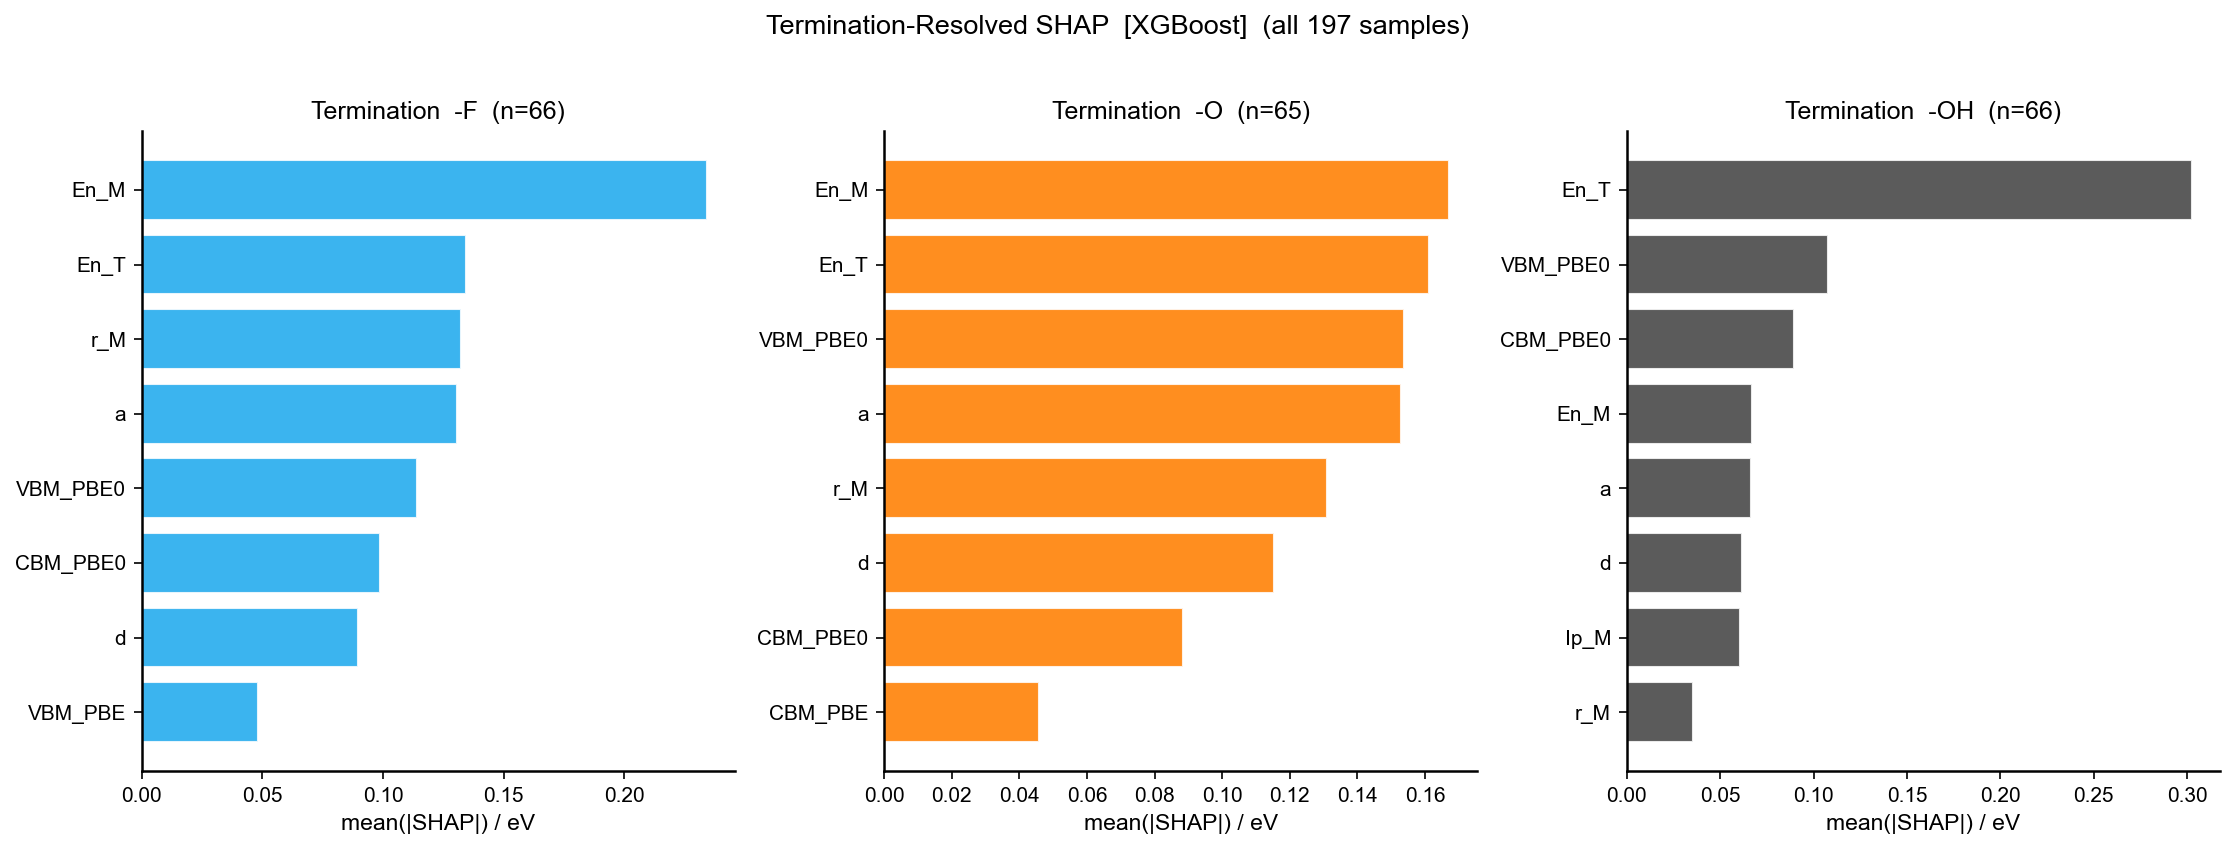

Top-5 features per termination:
  -F : ['En_M', 'En_T', 'r_M', 'a', 'VBM_PBE0']
  -O : ['En_M', 'En_T', 'VBM_PBE0', 'a', 'r_M']
  -OH : ['En_T', 'VBM_PBE0', 'CBM_PBE0', 'En_M', 'a']

Top-1 descriptor per termination (for manuscript):
  -F : En_M=0.234 eV  |  2nd=En_T=0.135 eV  |  ratio=1.73x
  -O : En_M=0.167 eV  |  2nd=En_T=0.161 eV  |  ratio=1.04x
  -OH : En_T=0.302 eV  |  2nd=VBM_PBE0=0.108 eV  |  ratio=2.8x

Saved: Table08_SHAP_term_F.csv
Saved: Table08_SHAP_term_O.csv
Saved: Table08_SHAP_term_OH.csv
Cell 13 complete


In [26]:
# Cell 13  分终端 SHAP 对比（基于全部197个样本）
# Cell 13  分终端 SHAP 对比（基于全部197个样本）
print("=" * 60)
print("Cell 13: Termination-Resolved SHAP Comparison (all 197 samples)")
print("=" * 60)

TOPK_TERM = 8
term_order      = ["F", "O", "OH"]
term_colors_map = {"F": COLOR_BLUE, "O": COLOR_ORANGE, "OH": COLOR_GRAY}

# ── 复用 Cell 10 的 shap_vals（已基于全部197个样本）──────────────────
shap_num_all  = shap_vals[:, n_ohe:]
term_col_all  = df[COL_T].values

print("Total samples for termination-resolved SHAP : " + str(len(term_col_all)))
for term in term_order:
    n_term = int((term_col_all == term).sum())
    print("  -" + term + " : " + str(n_term) + " samples")

term_shap_dfs = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

for ax, term in zip(axes, term_order):
    indices = [i for i, t in enumerate(term_col_all) if t == term]

    if len(indices) == 0:
        ax.set_title("-" + term + "  (no samples)")
        continue

    shap_sub = shap_num_all[indices, :]
    mean_abs = np.abs(shap_sub).mean(axis=0)

    df_ts = pd.DataFrame({
        "feature":       num_cols,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False).head(TOPK_TERM)

    term_shap_dfs[term] = df_ts

    df_plot_ts = df_ts.iloc[::-1]
    ax.barh(
        df_plot_ts["feature"],
        df_plot_ts["mean_abs_shap"],
        color=term_colors_map[term],
        alpha=0.88, edgecolor="white"
    )
    ax.set_xlabel("mean(|SHAP|) / eV")
    ax.set_title(
        "Termination  -" + term +
        "  (n=" + str(len(indices)) + ")"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Termination-Resolved SHAP  [" + shap_model_name + "]  (all 197 samples)",
    fontsize=13, y=1.02
)
plt.tight_layout()
save_fig("Fig09_SHAP_termination_grouped")
plt.show()

# ── Top-5 重叠分析 ────────────────────────────────────────────────────
print("Top-5 features per termination:")
for term, df_ts in term_shap_dfs.items():
    top5 = df_ts["feature"].head(5).tolist()
    print("  -" + term + " : " + str(top5))

# ── 各终端 Top-1 描述符数值汇总（用于正文数值核对）─────────────────
print("")
print("Top-1 descriptor per termination (for manuscript):")
for term, df_ts in term_shap_dfs.items():
    top1_feat = df_ts.iloc[0]["feature"]
    top1_val  = round(float(df_ts.iloc[0]["mean_abs_shap"]), 3)
    top2_feat = df_ts.iloc[1]["feature"]
    top2_val  = round(float(df_ts.iloc[1]["mean_abs_shap"]), 3)
    ratio     = round(top1_val / top2_val, 2)
    print("  -" + term + " : " + top1_feat + "=" + str(top1_val) + " eV"
          + "  |  2nd=" + top2_feat + "=" + str(top2_val) + " eV"
          + "  |  ratio=" + str(ratio) + "x")

# ── 保存 ─────────────────────────────────────────────────────────────
for term, df_ts in term_shap_dfs.items():
    df_ts.to_csv(
        os.path.join(OUTDIR, "Table08_SHAP_term_" + term + ".csv"),
        index=False, encoding="utf-8-sig"
    )
print("")
print("Saved: Table08_SHAP_term_F.csv")
print("Saved: Table08_SHAP_term_O.csv")
print("Saved: Table08_SHAP_term_OH.csv")
print("Cell 13 complete")




Cell 14 — PDP 物理响应曲线 +  窗口

Cell 14: Partial Dependence Plots + Application Windows
PDP features : ['En_T', 'En_M', 'a', 'VBM_PBE0']
  Saved: Fig10_PDP_OSC_window.png / .tiff


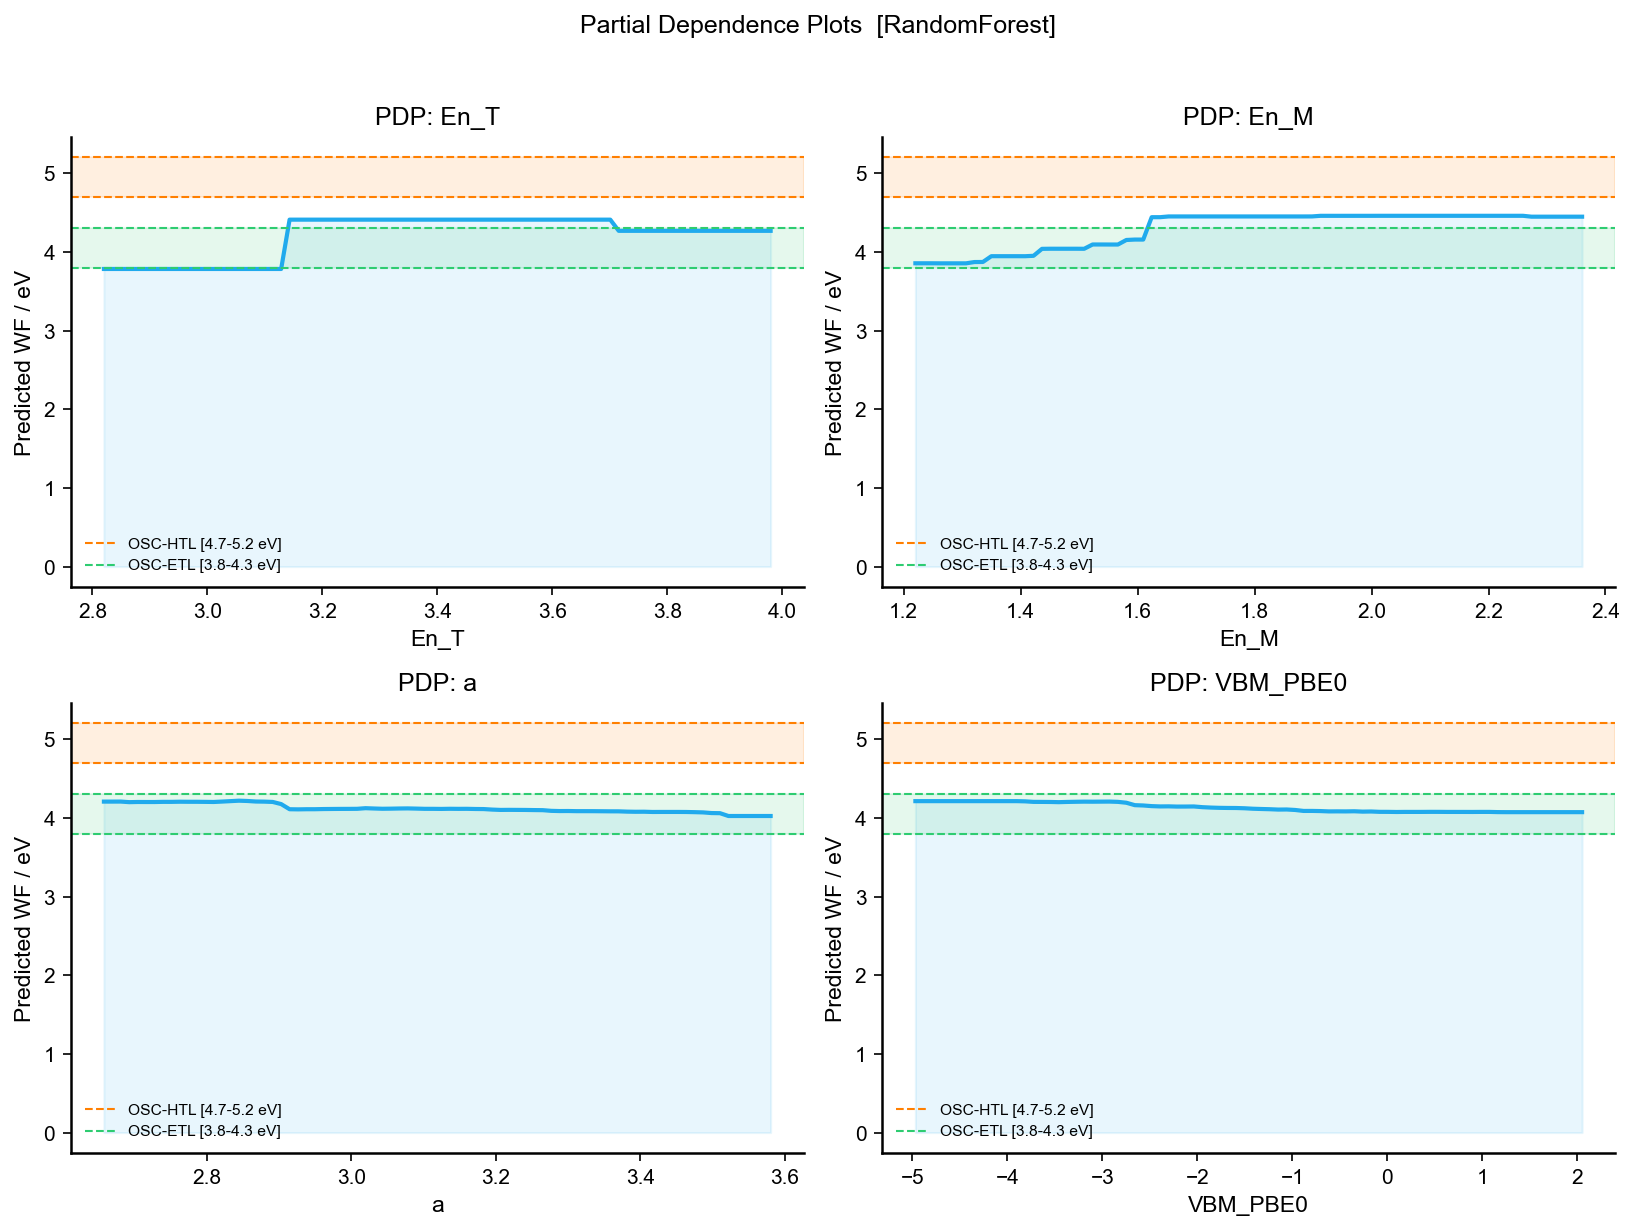


OSC-HTL candidates  (4.7-5.2 eV):
  Total : 17 / 197  (8.6%)
  By termination :
F    10
O     7
  By metal :
Nb    4
Ta    4
W     2
Zr    2
Cr    2
Ti    1
Hf    1
Sc    1
  Saved: Table09_OSC-HTL_candidates.csv

OSC-ETL candidates  (3.8-4.3 eV):
  Total : 7 / 197  (3.6%)
  By termination :
F    6
O    1
  By metal :
Zr    2
Sc    2
Ta    1
Y     1
Nb    1
  Saved: Table09_OSC-ETL_candidates.csv

[Fig10 Origin 导出]
  Saved: Fig10_PDP_En_T.csv
  Saved: Fig10_PDP_En_M.csv
  Saved: Fig10_PDP_a.csv
  Saved: Fig10_PDP_VBM_PBE0.csv
  Saved: Fig10_PDP_window_reflines.csv

Cell 14 complete ✓


In [14]:
# ============================================================
# Cell 14  PDP 物理响应曲线（OSC HTL + OSC ETL 双窗口）
# ============================================================
print("=" * 60)
print("Cell 14: Partial Dependence Plots + Application Windows")
print("=" * 60)

# ── 窗口参数 ──────────────────────────────────────────────────────────
OSC_WF_LO  = 4.7   # OSC HTL 下限
OSC_WF_HI  = 5.2   # OSC HTL 上限
OSC_ETL_LO = 3.8   # OSC ETL 下限
OSC_ETL_HI = 4.3   # OSC ETL 上限

# ── SHAP Top-4 数值描述符 ─────────────────────────────────────────────
top4_feats = [
    f for f in df_shap_topk["feature"].tolist()
    if f in num_cols
][:4]
print("PDP features : " + str(top4_feats))

# ── PDP 绘图 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_flat  = axes.flatten()

for ax, feat in zip(axes_flat, top4_feats):
    feat_vals  = df[feat].values.astype(float)
    feat_range = np.linspace(feat_vals.min(), feat_vals.max(), 80)

    pdp_vals = []
    for v in feat_range:
        X_mod       = X.copy()
        X_mod[feat] = v
        pdp_vals.append(float(best_pipe.predict(X_mod).mean()))
    pdp_vals = np.array(pdp_vals)

    ax.plot(feat_range, pdp_vals, color=COLOR_BLUE, linewidth=2.0)
    ax.fill_between(feat_range, pdp_vals, alpha=0.10, color=COLOR_BLUE)

    # OSC HTL 窗口（橙色）
    ax.axhspan(OSC_WF_LO, OSC_WF_HI, alpha=0.12, color=COLOR_ORANGE)
    ax.axhline(OSC_WF_LO, color=COLOR_ORANGE, lw=1.0, linestyle="--")
    ax.axhline(OSC_WF_HI, color=COLOR_ORANGE, lw=1.0, linestyle="--",
               label=f"OSC-HTL [{OSC_WF_LO}-{OSC_WF_HI} eV]")

    # OSC ETL 窗口（绿色）
    ax.axhspan(OSC_ETL_LO, OSC_ETL_HI, alpha=0.12, color="#2ECC71")
    ax.axhline(OSC_ETL_LO, color="#2ECC71", lw=1.0, linestyle="--")
    ax.axhline(OSC_ETL_HI, color="#2ECC71", lw=1.0, linestyle="--",
               label=f"OSC-ETL [{OSC_ETL_LO}-{OSC_ETL_HI} eV]")

    ax.set_xlabel(feat)
    ax.set_ylabel("Predicted WF / eV")
    ax.set_title("PDP: " + feat)
    ax.legend(frameon=False, fontsize=7.5, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Partial Dependence Plots  [" + best_name + "]",
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig("Fig10_PDP_OSC_window")
plt.show()

# ── 候选材料统计 ──────────────────────────────────────────────────────
for win_key, win_lo, win_hi in [
    ("OSC-HTL", OSC_WF_LO,  OSC_WF_HI),
    ("OSC-ETL", OSC_ETL_LO, OSC_ETL_HI),
]:
    mask_win = (y >= win_lo) & (y <= win_hi)
    df_win   = df[mask_win].copy()
    print(f"\n{win_key} candidates  ({win_lo}-{win_hi} eV):")
    print(f"  Total : {int(mask_win.sum())} / {len(y)}"
          f"  ({round(100 * mask_win.mean(), 1)}%)")
    print("  By termination :\n" + df_win[COL_T].value_counts().to_string())
    print("  By metal :\n"       + df_win[COL_M].value_counts().to_string())
    df_win[["name", COL_M, COL_X, COL_T, "n", COL_Y]].to_csv(
        os.path.join(OUTDIR, f"Table09_{win_key}_candidates.csv"),
        index=False, encoding="utf-8-sig"
    )
    print(f"  Saved: Table09_{win_key}_candidates.csv")

# ── Origin 导出：Fig10 PDP 原始数据 ───────────────────────────────────
print("\n[Fig10 Origin 导出]")

for feat in top4_feats:
    feat_vals  = df[feat].values.astype(float)
    feat_range = np.linspace(feat_vals.min(), feat_vals.max(), 80)

    pdp_vals = []
    for v in feat_range:
        X_mod       = X.copy()
        X_mod[feat] = v
        pdp_vals.append(float(best_pipe.predict(X_mod).mean()))

    pd.DataFrame({
        f"{feat}_value":  np.round(feat_range, 5),
        "PredictedWF_eV": np.round(pdp_vals,   4),
    }).to_csv(
        os.path.join(OUTDIR, f"Fig10_PDP_{feat}.csv"),
        index=False, encoding="utf-8-sig"
    )
    print(f"  Saved: Fig10_PDP_{feat}.csv")

# 参考线位置（12条，六窗口上下边界）
pd.DataFrame([
    {"Window": "OSC-HTL_Lo",   "WF_eV": OSC_WF_LO,  "Color_Hex": COLOR_ORANGE, "Line_Style": "Dash"},
    {"Window": "OSC-HTL_Hi",   "WF_eV": OSC_WF_HI,  "Color_Hex": COLOR_ORANGE, "Line_Style": "Dash"},
    {"Window": "OSC-ETL_Lo",   "WF_eV": OSC_ETL_LO, "Color_Hex": "#2ECC71",    "Line_Style": "Dash"},
    {"Window": "OSC-ETL_Hi",   "WF_eV": OSC_ETL_HI, "Color_Hex": "#2ECC71",    "Line_Style": "Dash"},
    {"Window": "Perov-HTL_Lo", "WF_eV": 5.0,         "Color_Hex": "#C0392B",    "Line_Style": "Dash"},
    {"Window": "Perov-HTL_Hi", "WF_eV": 5.6,         "Color_Hex": "#C0392B",    "Line_Style": "Dash"},
    {"Window": "Perov-ETL_Lo", "WF_eV": 3.7,         "Color_Hex": "#8E44AD",    "Line_Style": "Dash"},
    {"Window": "Perov-ETL_Hi", "WF_eV": 4.5,         "Color_Hex": "#8E44AD",    "Line_Style": "Dash"},
    {"Window": "HJT-p_Lo",     "WF_eV": 5.0,         "Color_Hex": "#E74C3C",    "Line_Style": "Dash"},
    {"Window": "HJT-p_Hi",     "WF_eV": 5.4,         "Color_Hex": "#E74C3C",    "Line_Style": "Dash"},
    {"Window": "HJT-n_Lo",     "WF_eV": 3.9,         "Color_Hex": "#2980B9",    "Line_Style": "Dash"},
    {"Window": "HJT-n_Hi",     "WF_eV": 4.4,         "Color_Hex": "#2980B9",    "Line_Style": "Dash"},
]).to_csv(
    os.path.join(OUTDIR, "Fig10_PDP_window_reflines.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: Fig10_PDP_window_reflines.csv")
print("\nCell 14 complete ✓")


Cell 14-B: Multi-Application Window Screening

[Step 1] Per-window candidate screening
-------------------------------------------------------

  [OSC-HTL]  WF 4.7–5.2 eV  →  17 candidates (8.6%)
    Termination : {'F': 10, 'O': 7}
    Metal       : {'Nb': 4, 'Ta': 4, 'Zr': 2, 'Cr': 2, 'W': 2, 'Ti': 1, 'Hf': 1, 'Sc': 1}
    Saved: Table_Candidates_OSC-HTL.csv

  [OSC-ETL]  WF 3.8–4.3 eV  →  7 candidates (3.6%)
    Termination : {'F': 6, 'O': 1}
    Metal       : {'Zr': 2, 'Sc': 2, 'Ta': 1, 'Nb': 1, 'Y': 1}
    Saved: Table_Candidates_OSC-ETL.csv

  [Perov-HTL]  WF 5.0–5.6 eV  →  32 candidates (16.2%)
    Termination : {'O': 17, 'F': 15}
    Metal       : {'Ta': 7, 'Nb': 6, 'W': 4, 'V': 4, 'Sc': 2, 'Cr': 2, 'Y': 2, 'Zr': 2, 'Hf': 1, 'Mo': 1, 'Ti': 1}
    Saved: Table_Candidates_Perov-HTL.csv

  [Perov-ETL]  WF 3.7–4.5 eV  →  19 candidates (9.6%)
    Termination : {'F': 16, 'O': 3}
    Metal       : {'Ta': 4, 'Sc': 3, 'Zr': 3, 'Nb': 2, 'Y': 2, 'Ti': 2, 'Cr': 1, 'Hf': 1, 'W': 1}
    Saved

,name,M_label,X_label,T_label,n,WF_DFT_eV,OSC-HTL,OSC-ETL,Perov-HTL,Perov-ETL,HJT-p,HJT-n,N_windows_matched
0,Nb4N3F2,Nb,N,F,3,4.235459,0,1,0,1,0,1,3
1,Zr2CF2,Zr,C,F,1,3.905669,0,1,0,1,0,1,3
2,Sc4C3F2,Sc,C,F,3,5.059854,1,0,1,0,1,0,3
3,Ta3C2O2,Ta,C,O,2,5.011134,1,0,1,0,1,0,3
4,Ta4N3O2,Ta,N,O,3,5.005655,1,0,1,0,1,0,3
5,Nb3C2O2,Nb,C,O,2,5.194495,1,0,1,0,1,0,3
6,W2NF2,W,N,F,1,5.131546,1,0,1,0,1,0,3
7,Y4C3F2,Y,C,F,3,4.287109,0,1,0,1,0,1,3
8,Sc3N2F2,Sc,N,F,2,4.029499,0,1,0,1,0,1,3
9,Cr4N3F2,Cr,N,F,3,5.184955,1,0,1,0,1,0,3



[Step 3] Pairwise window overlap analysis
-------------------------------------------------------
  OSC-HTL ∩ Perov-HTL: 9 candidates
    → Sc4C3F2, Ta3C2O2, Ta4N3O2, Nb3C2O2, W2NF2, Cr4N3F2, Nb2NF2, Ta3N2F2 ...
  OSC-HTL ∩ HJT-p: 9 candidates
    → Sc4C3F2, Ta3C2O2, Ta4N3O2, Nb3C2O2, W2NF2, Cr4N3F2, Nb2NF2, Ta3N2F2 ...
  OSC-ETL ∩ Perov-ETL: 7 candidates
    → Nb4N3F2, Zr2CF2, Y4C3F2, Sc3N2F2, Sc3C2O2, Zr3N2F2, Ta2CF2
  OSC-ETL ∩ HJT-n: 5 candidates
    → Nb4N3F2, Zr2CF2, Y4C3F2, Sc3N2F2, Sc3C2O2
  Perov-HTL ∩ HJT-p: 24 candidates
    → Sc4C3F2, Ta3C2O2, Ta4N3O2, Nb3C2O2, W2NF2, Cr4N3F2, Nb2NF2, Ta3N2F2 ...
  Perov-ETL ∩ HJT-n: 10 candidates
    → Nb4N3F2, Zr2CF2, Y4C3F2, Sc3N2F2, Sc3C2O2, Hf3N2O2, Ta4C3F2, W4N3F2 ...

Saved: window_overlap_matrix.csv
Saved: window_overlap_details.csv

[Step 4] Visualization
  Saved: Fig12_window_screening_overview.png / .tiff


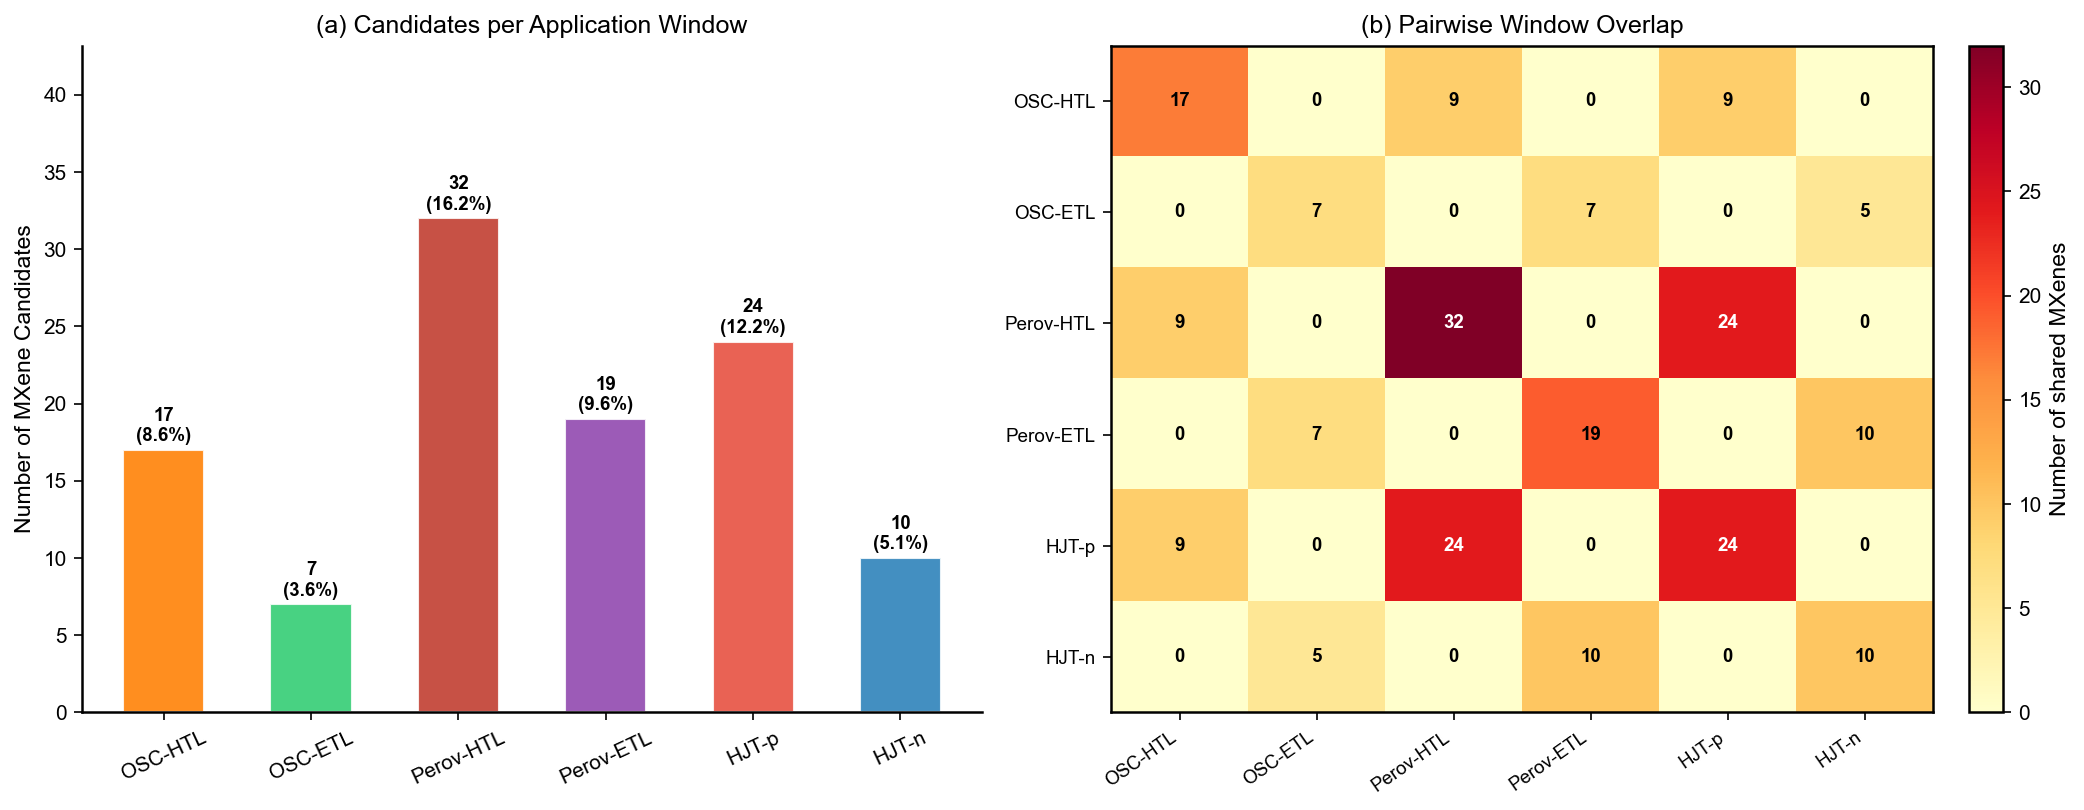

  Saved: Fig13_WF_landscape_all_windows.png / .tiff


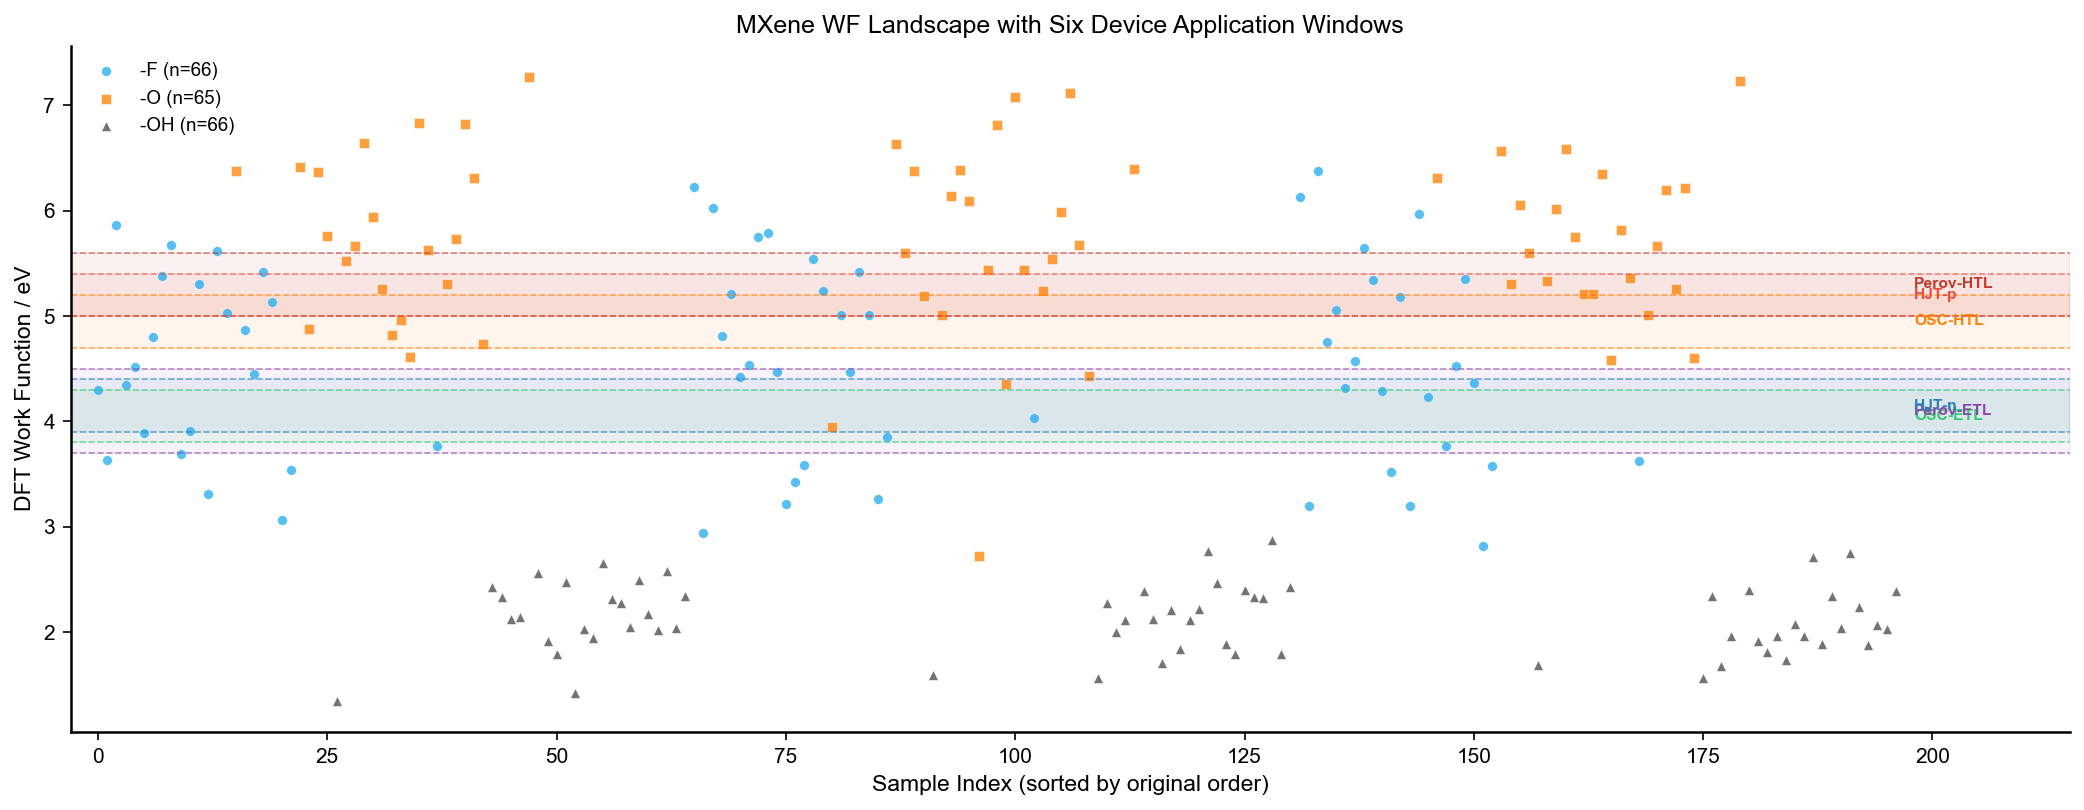

  Saved: Fig14_candidates_per_window.png / .tiff


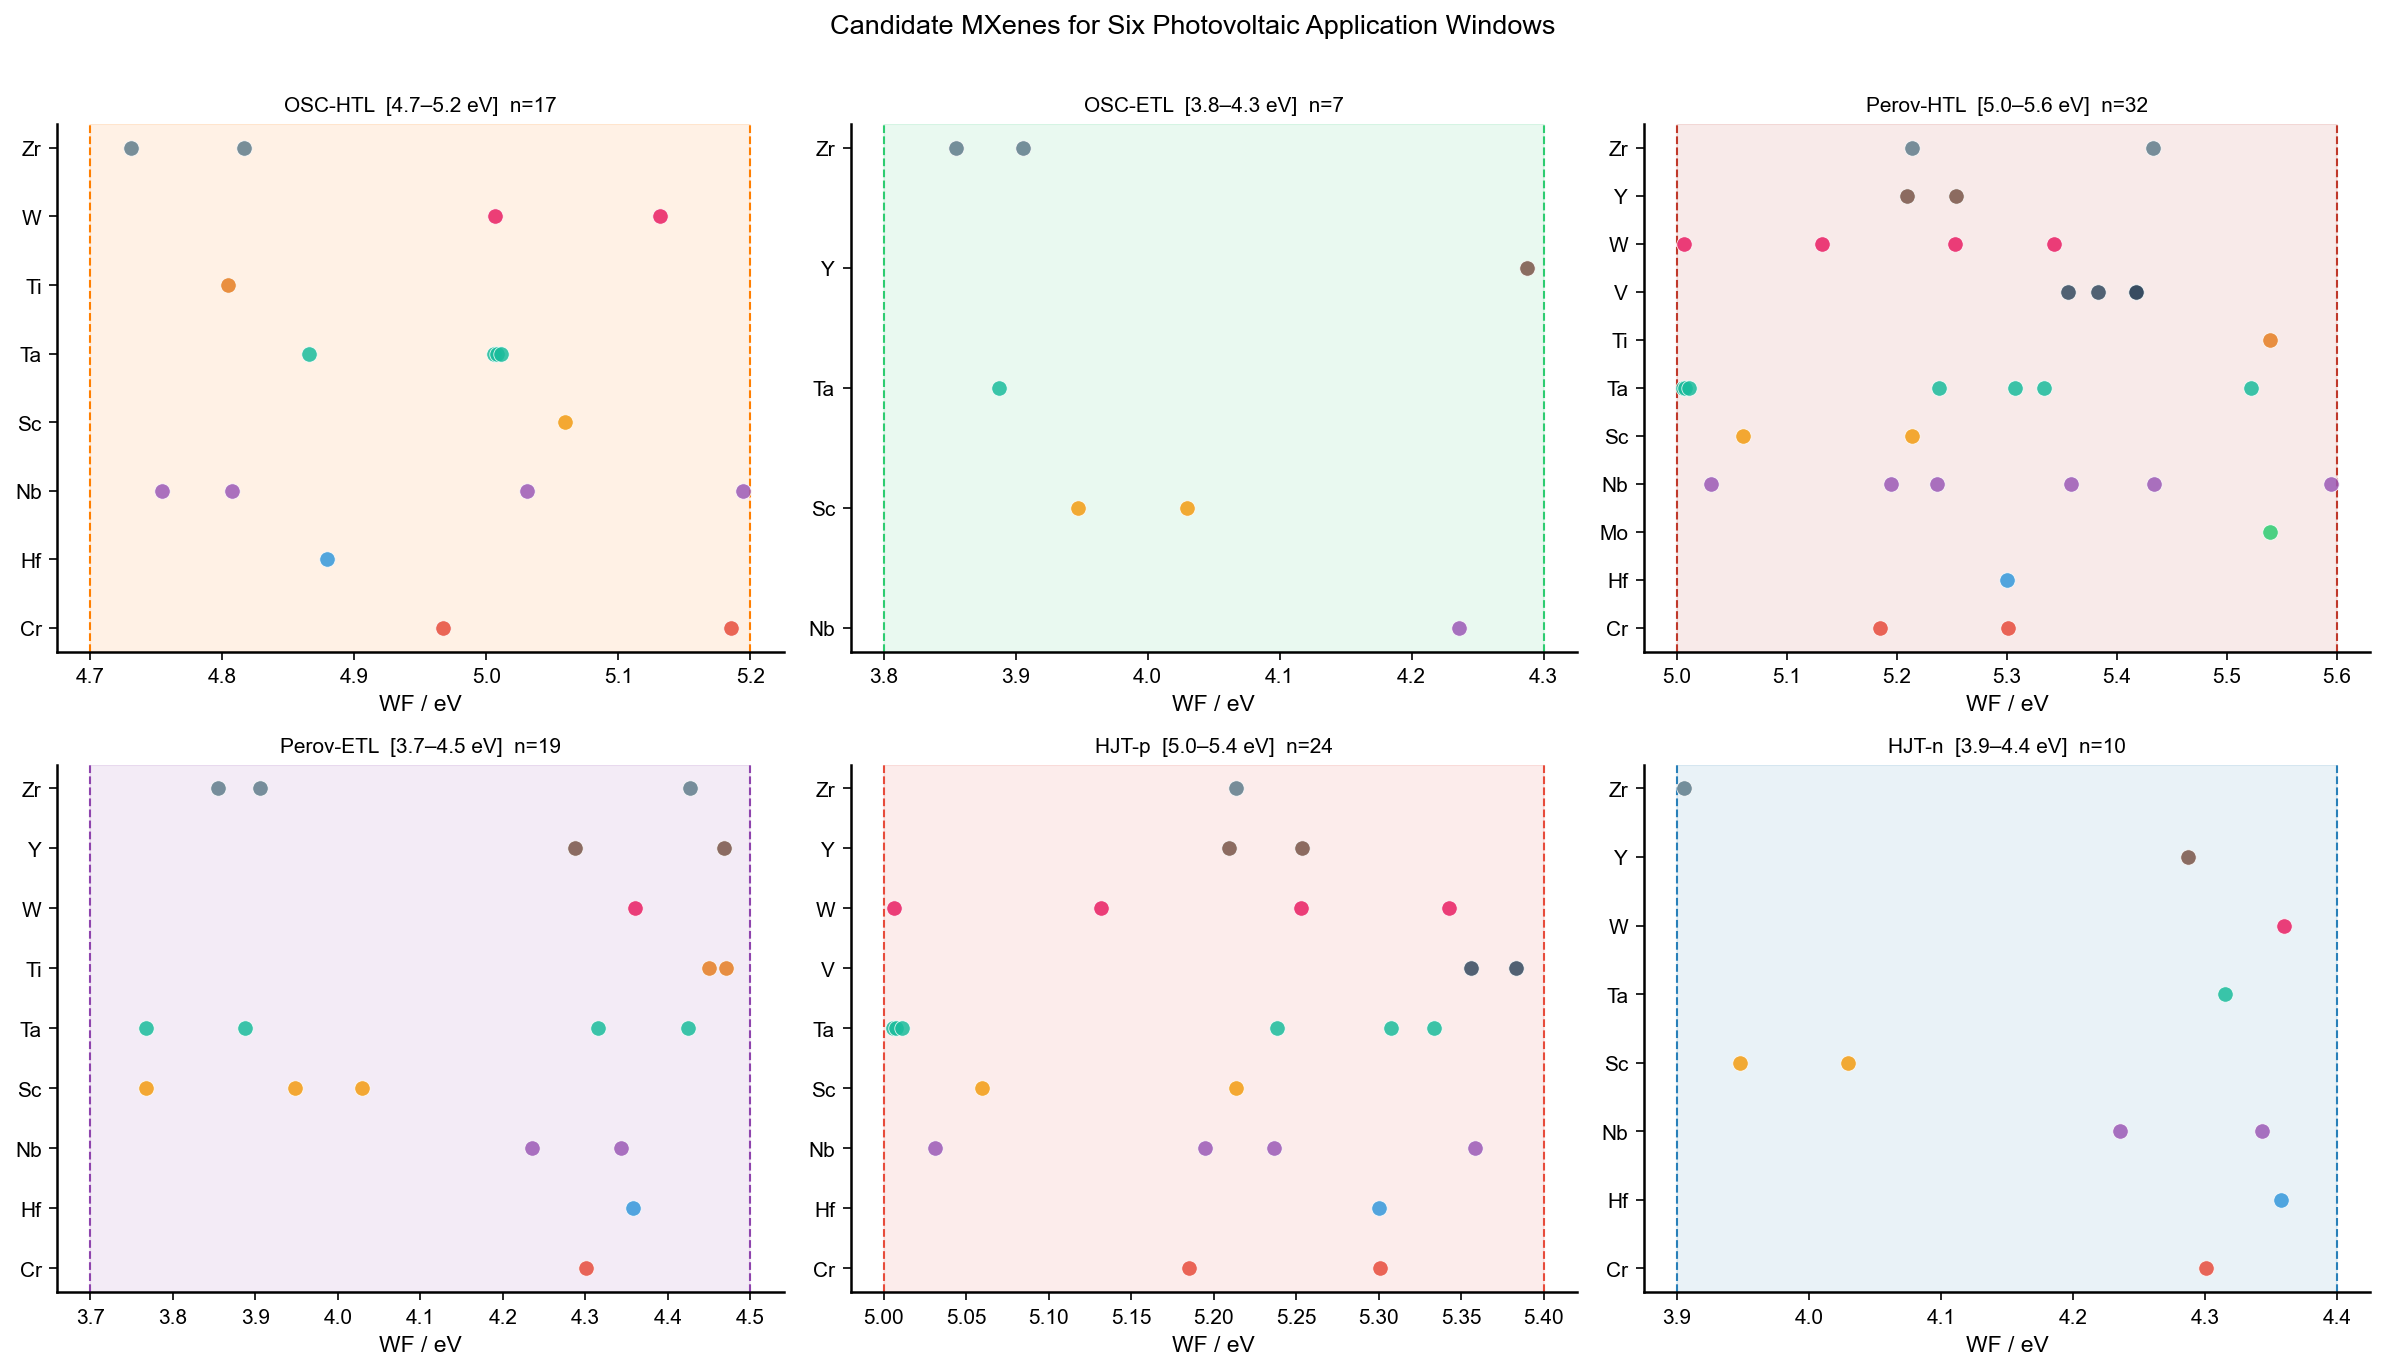


Saved: Table_All_Candidates_combined.csv
Total candidate-window entries : 109
Unique MXene compositions      : 59

Cell 14-B complete ✓
导出文件汇总：
  Table_Candidates_OSC-HTL.csv
  Table_Candidates_OSC-ETL.csv
  Table_Candidates_Perov-HTL.csv
  Table_Candidates_Perov-ETL.csv
  Table_Candidates_HJT-p.csv
  Table_Candidates_HJT-n.csv
  application_candidate_counts.csv
  multi_application_WF_windows.csv
  window_overlap_matrix.csv
  window_overlap_details.csv
  Table_All_Candidates_combined.csv
图表：
  Fig12_window_screening_overview.png/.tiff
  Fig13_WF_landscape_all_windows.png/.tiff
  Fig14_candidates_per_window.png/.tiff


In [15]:
# ============================================================
# Cell 14-B  多应用窗口筛选 + 候选清单导出
# ============================================================
print("=" * 60)
print("Cell 14-B: Multi-Application Window Screening")
print("=" * 60)

import itertools

# ── 六个应用窗口定义 ──────────────────────────────────────────────────
APP_WINDOWS = {
    "OSC-HTL":   {"lo": 4.7, "hi": 5.2,
                  "color": COLOR_ORANGE,
                  "desc": "Organic SC Hole Transport Layer"},
    "OSC-ETL":   {"lo": 3.8, "hi": 4.3,
                  "color": "#2ECC71",
                  "desc": "Organic SC Electron Transport Layer"},
    "Perov-HTL": {"lo": 5.0, "hi": 5.6,
                  "color": "#C0392B",
                  "desc": "Perovskite SC Hole Transport Layer"},
    "Perov-ETL": {"lo": 3.7, "hi": 4.5,
                  "color": "#8E44AD",
                  "desc": "Perovskite SC Electron Transport Layer"},
    "HJT-p":     {"lo": 5.0, "hi": 5.4,
                  "color": "#E74C3C",
                  "desc": "HJT Silicon p-contact"},
    "HJT-n":     {"lo": 3.9, "hi": 4.4,
                  "color": "#2980B9",
                  "desc": "HJT Silicon n-contact"},
}

# ── 1. 各窗口候选材料筛选 + 单独导出 ─────────────────────────────────
print("\n[Step 1] Per-window candidate screening")
print("-" * 55)

candidate_dfs   = {}   # 每个窗口的候选 DataFrame
candidate_counts = []  # 汇总计数行

for win_key, win in APP_WINDOWS.items():
    lo, hi = win["lo"], win["hi"]
    mask   = (df[COL_Y] >= lo) & (df[COL_Y] <= hi)
    df_win = df[mask][
        ["name", COL_M, COL_X, COL_T, "n", COL_Y, "a", "d", "HoF"]
    ].copy().sort_values(COL_Y).reset_index(drop=True)
    df_win.rename(columns={COL_Y: "WF_DFT_eV"}, inplace=True)

    candidate_dfs[win_key] = df_win
    n_total = len(df_win)
    n_pct   = round(100 * n_total / len(df), 1)

    # 终端分布
    term_dist = df_win[COL_T].value_counts().to_dict()
    # 金属分布
    metal_dist = df_win[COL_M].value_counts().to_dict()
    # 主导终端
    dom_term  = df_win[COL_T].value_counts().idxmax() if n_total > 0 else "N/A"
    dom_metal = df_win[COL_M].value_counts().idxmax() if n_total > 0 else "N/A"

    candidate_counts.append({
        "Window":        win_key,
        "WF_Lo_eV":      lo,
        "WF_Hi_eV":      hi,
        "N_candidates":  n_total,
        "Pct_total":     n_pct,
        "Dom_Term":      dom_term,
        "Dom_Metal":     dom_metal,
        "Term_dist":     str(term_dist),
        "Metal_dist":    str(metal_dist),
        "Description":   win["desc"],
    })

    # 保存单窗口候选清单
    fname = f"Table_Candidates_{win_key}.csv"
    df_win.to_csv(os.path.join(OUTDIR, fname),
                  index=False, encoding="utf-8-sig")

    print(f"\n  [{win_key}]  WF {lo}–{hi} eV  →  {n_total} candidates ({n_pct}%)")
    print(f"    Termination : {term_dist}")
    print(f"    Metal       : {metal_dist}")
    print(f"    Saved: {fname}")

# ── 2. 汇总计数表 ─────────────────────────────────────────────────────
df_counts = pd.DataFrame(candidate_counts)
df_counts.to_csv(
    os.path.join(OUTDIR, "application_candidate_counts.csv"),
    index=False, encoding="utf-8-sig"
)
print("\nSaved: application_candidate_counts.csv")
print(df_counts[
    ["Window", "WF_Lo_eV", "WF_Hi_eV", "N_candidates",
     "Pct_total", "Dom_Term", "Dom_Metal"]
].to_string(index=False))

# ── 3. 多窗口汇总宽表（每行一个MXene，各窗口列为0/1标记）────────────
print("\n[Step 2] Multi-application WF windows wide table")
print("-" * 55)

df_multi = df[["name", COL_M, COL_X, COL_T, "n", COL_Y]].copy()
df_multi.rename(columns={COL_Y: "WF_DFT_eV"}, inplace=True)

for win_key, win in APP_WINDOWS.items():
    df_multi[win_key] = (
        (df_multi["WF_DFT_eV"] >= win["lo"]) &
        (df_multi["WF_DFT_eV"] <= win["hi"])
    ).astype(int)

df_multi["N_windows_matched"] = df_multi[
    list(APP_WINDOWS.keys())
].sum(axis=1)

df_multi_sorted = df_multi.sort_values(
    "N_windows_matched", ascending=False
).reset_index(drop=True)

df_multi_sorted.to_csv(
    os.path.join(OUTDIR, "multi_application_WF_windows.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: multi_application_WF_windows.csv")

# 打印匹配多个窗口的材料
multi_match = df_multi_sorted[df_multi_sorted["N_windows_matched"] >= 2]
print(f"\nMXenes matching ≥ 2 windows: {len(multi_match)}")
if len(multi_match) > 0:
    display(multi_match.head(15))

# ── 4. 窗口重叠分析（两两交集）──────────────────────────────────────
print("\n[Step 3] Pairwise window overlap analysis")
print("-" * 55)

win_keys = list(APP_WINDOWS.keys())
overlap_matrix = pd.DataFrame(
    np.zeros((len(win_keys), len(win_keys)), dtype=int),
    index=win_keys, columns=win_keys
)
overlap_details = []

for w1, w2 in itertools.combinations(win_keys, 2):
    mask1 = df_multi_sorted[w1] == 1
    mask2 = df_multi_sorted[w2] == 1
    n_overlap = int((mask1 & mask2).sum())
    overlap_matrix.loc[w1, w2] = n_overlap
    overlap_matrix.loc[w2, w1] = n_overlap
    if n_overlap > 0:
        overlap_names = df_multi_sorted.loc[
            mask1 & mask2, "name"
        ].tolist()
        overlap_details.append({
            "Window_A":    w1,
            "Window_B":    w2,
            "N_overlap":   n_overlap,
            "Candidates":  ", ".join(overlap_names),
        })
        print(f"  {w1} ∩ {w2}: {n_overlap} candidates")
        print(f"    → {', '.join(overlap_names[:8])}"
              + (" ..." if len(overlap_names) > 8 else ""))

# 对角线填充各窗口自身数量
for w in win_keys:
    overlap_matrix.loc[w, w] = int((df_multi_sorted[w] == 1).sum())

overlap_matrix.to_csv(
    os.path.join(OUTDIR, "window_overlap_matrix.csv"),
    encoding="utf-8-sig"
)
pd.DataFrame(overlap_details).to_csv(
    os.path.join(OUTDIR, "window_overlap_details.csv"),
    index=False, encoding="utf-8-sig"
)
print("\nSaved: window_overlap_matrix.csv")
print("Saved: window_overlap_details.csv")

# ── 5. 可视化 A：各窗口候选数量条形图 ────────────────────────────────
print("\n[Step 4] Visualization")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 左图：候选数量
ax1 = axes[0]
bar_colors_win = [APP_WINDOWS[w]["color"] for w in df_counts["Window"]]
bars = ax1.bar(
    df_counts["Window"], df_counts["N_candidates"],
    color=bar_colors_win, alpha=0.88, edgecolor="white", width=0.55
)
for bar, row in zip(bars, df_counts.itertuples()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row.N_candidates}\n({row.Pct_total}%)",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
ax1.set_ylabel("Number of MXene Candidates")
ax1.set_title("(a) Candidates per Application Window")
ax1.set_ylim(0, df_counts["N_candidates"].max() * 1.35)
ax1.tick_params(axis="x", labelrotation=25)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# 右图：窗口重叠热图
ax2 = axes[1]
im = ax2.imshow(
    overlap_matrix.values.astype(float),
    cmap="YlOrRd", aspect="auto"
)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04,
             label="Number of shared MXenes")
ax2.set_xticks(range(len(win_keys)))
ax2.set_yticks(range(len(win_keys)))
ax2.set_xticklabels(win_keys, rotation=35, ha="right", fontsize=9)
ax2.set_yticklabels(win_keys, fontsize=9)
ax2.set_title("(b) Pairwise Window Overlap")

for i in range(len(win_keys)):
    for j in range(len(win_keys)):
        val = overlap_matrix.values[i, j]
        txt_c = "white" if val > overlap_matrix.values.max() * 0.6 else "black"
        ax2.text(j, i, str(int(val)),
                 ha="center", va="center",
                 fontsize=9, color=txt_c, fontweight="bold")

plt.tight_layout()
save_fig("Fig12_window_screening_overview")
plt.show()

# ── 6. 可视化 B：所有候选材料 WF 散点图（按窗口分色）────────────────
fig, ax = plt.subplots(figsize=(14, 5.5))

# 背景窗口色带
for win_key, win in APP_WINDOWS.items():
    ax.axhspan(win["lo"], win["hi"],
               alpha=0.07, color=win["color"])
    ax.axhline(win["lo"], color=win["color"],
               lw=0.8, linestyle="--", alpha=0.6)
    ax.axhline(win["hi"], color=win["color"],
               lw=0.8, linestyle="--", alpha=0.6)
    ax.text(
        len(df) + 1, (win["lo"] + win["hi"]) / 2,
        win_key, va="center", ha="left",
        fontsize=7.5, color=win["color"], fontweight="bold"
    )

# 按终端分色绘制所有样本
term_marker = {"F": "o", "O": "s", "OH": "^"}
for term in ["F", "O", "OH"]:
    mask_t = df[COL_T] == term
    idx    = df[mask_t].index
    ax.scatter(
        idx, df.loc[mask_t, COL_Y],
        color=term_colors[term],
        marker=term_marker[term],
        s=22, alpha=0.75,
        edgecolor="white", linewidth=0.3,
        label=f"-{term} (n={int(mask_t.sum())})"
    )

ax.set_xlabel("Sample Index (sorted by original order)")
ax.set_ylabel("DFT Work Function / eV")
ax.set_title("MXene WF Landscape with Six Device Application Windows")
ax.set_xlim(-3, len(df) + 18)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig("Fig13_WF_landscape_all_windows")
plt.show()

# ── 7. 可视化 C：各窗口候选材料 WF 分布（按金属分色）────────────────
n_wins   = len(APP_WINDOWS)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

metal_palette = {
    "Cr": "#E74C3C", "Hf": "#3498DB", "Mo": "#2ECC71",
    "Nb": "#9B59B6", "Sc": "#F39C12", "Ta": "#1ABC9C",
    "Ti": "#E67E22", "V":  "#34495E", "W":  "#E91E63",
    "Y":  "#795548", "Zr": "#607D8B",
}

for ax, (win_key, win) in zip(axes_flat, APP_WINDOWS.items()):
    df_w = candidate_dfs[win_key]
    if len(df_w) == 0:
        ax.text(0.5, 0.5, "No candidates", ha="center",
                va="center", transform=ax.transAxes)
        ax.set_title(win_key)
        continue

    for metal in sorted(df_w[COL_M].unique()):
        mask_m = df_w[COL_M] == metal
        wf_m   = df_w.loc[mask_m, "WF_DFT_eV"].values
        ax.scatter(
            wf_m,
            [metal] * len(wf_m),
            color=metal_palette.get(metal, COLOR_GRAY),
            s=55, alpha=0.85,
            edgecolor="white", linewidth=0.4,
            zorder=3
        )

    ax.axvspan(win["lo"], win["hi"], alpha=0.10, color=win["color"])
    ax.axvline(win["lo"], color=win["color"], lw=1.0, linestyle="--")
    ax.axvline(win["hi"], color=win["color"], lw=1.0, linestyle="--")
    ax.set_xlabel("WF / eV")
    ax.set_title(
        f"{win_key}  [{win['lo']}–{win['hi']} eV]"
        f"  n={len(df_w)}",
        fontsize=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Candidate MXenes for Six Photovoltaic Application Windows",
    fontsize=13, y=1.01
)
plt.tight_layout()
save_fig("Fig14_candidates_per_window")
plt.show()

# ── 8. 合并全候选清单（去重，注明适用窗口）──────────────────────────
all_cand_rows = []
for win_key, df_w in candidate_dfs.items():
    for _, row in df_w.iterrows():
        all_cand_rows.append({
            "name":       row["name"],
            COL_M:        row[COL_M],
            COL_X:        row[COL_X],
            COL_T:        row[COL_T],
            "n":          row["n"],
            "WF_DFT_eV":  row["WF_DFT_eV"],
            "Window":     win_key,
            "WF_Lo_eV":   APP_WINDOWS[win_key]["lo"],
            "WF_Hi_eV":   APP_WINDOWS[win_key]["hi"],
        })

df_all_cand = pd.DataFrame(all_cand_rows).sort_values(
    ["name", "Window"]
).reset_index(drop=True)

df_all_cand.to_csv(
    os.path.join(OUTDIR, "Table_All_Candidates_combined.csv"),
    index=False, encoding="utf-8-sig"
)
print("\nSaved: Table_All_Candidates_combined.csv")
print(f"Total candidate-window entries : {len(df_all_cand)}")
print(f"Unique MXene compositions      : "
      f"{df_all_cand['name'].nunique()}")

# ── 完成汇报 ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Cell 14-B complete ✓")
print("导出文件汇总：")
for win_key in APP_WINDOWS:
    print(f"  Table_Candidates_{win_key}.csv")
print("  application_candidate_counts.csv")
print("  multi_application_WF_windows.csv")
print("  window_overlap_matrix.csv")
print("  window_overlap_details.csv")
print("  Table_All_Candidates_combined.csv")
print("图表：")
print("  Fig12_window_screening_overview.png/.tiff")
print("  Fig13_WF_landscape_all_windows.png/.tiff")
print("  Fig14_candidates_per_window.png/.tiff")
print("=" * 60)


Cell 15 设计规则矩阵 + 混合终端展望

Cell 15: Design Rule Matrix + Mixed Termination Outlook
  Saved: Fig11_design_rule_matrix.png / .tiff


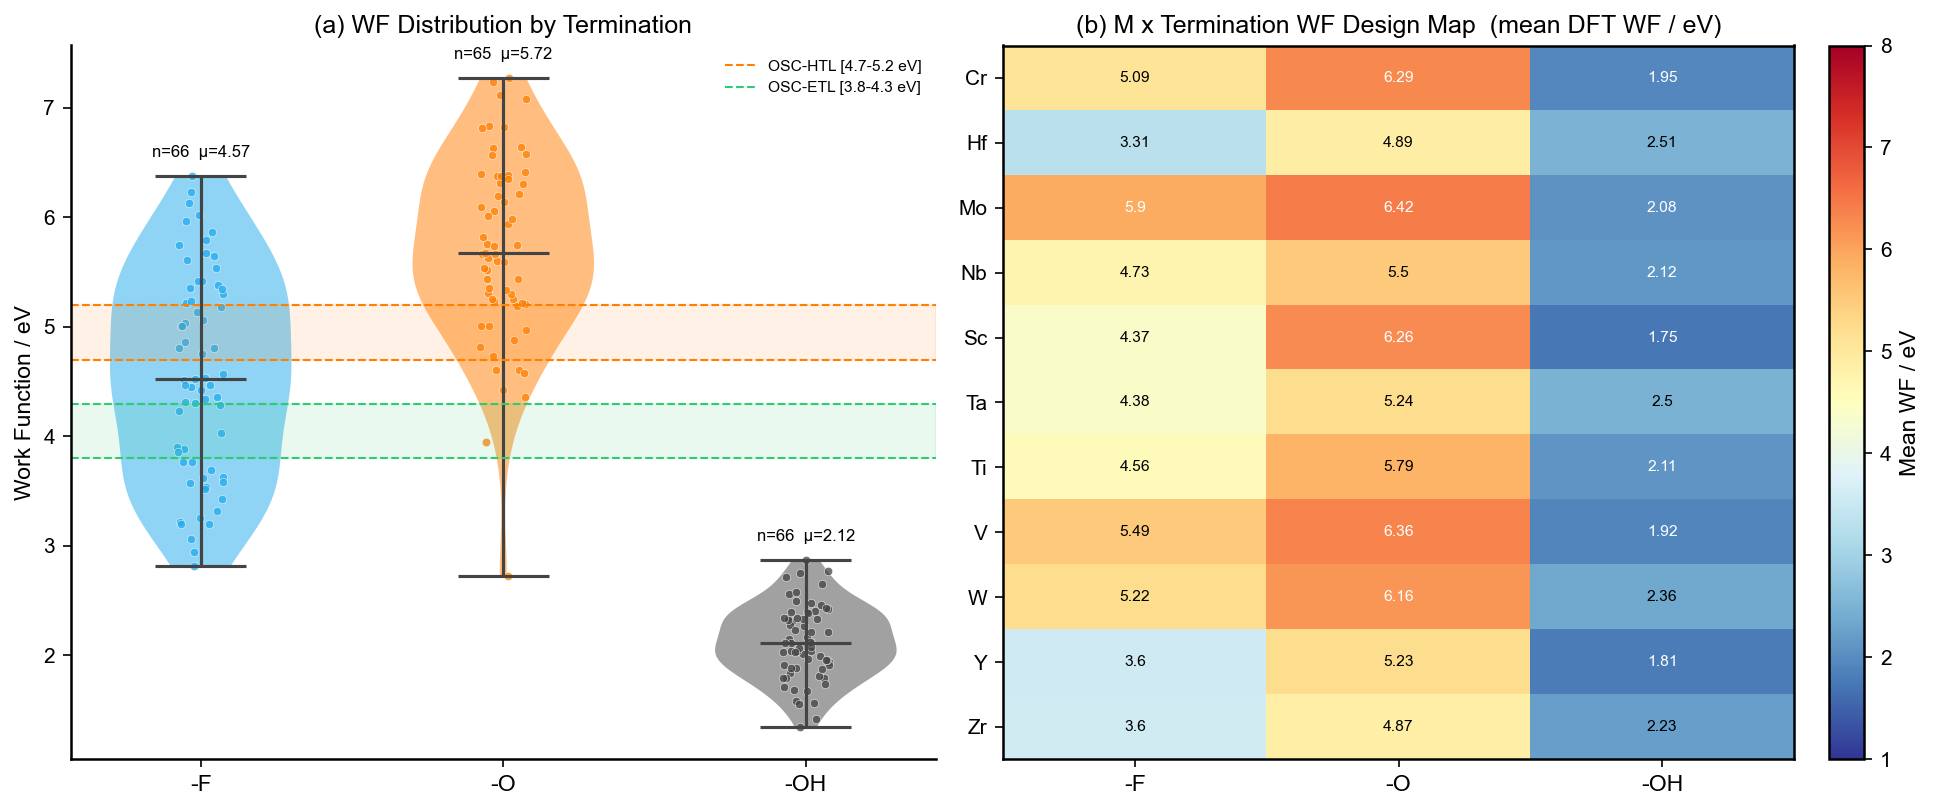

  Saved: Fig15_mixed_termination_outlook.png / .tiff


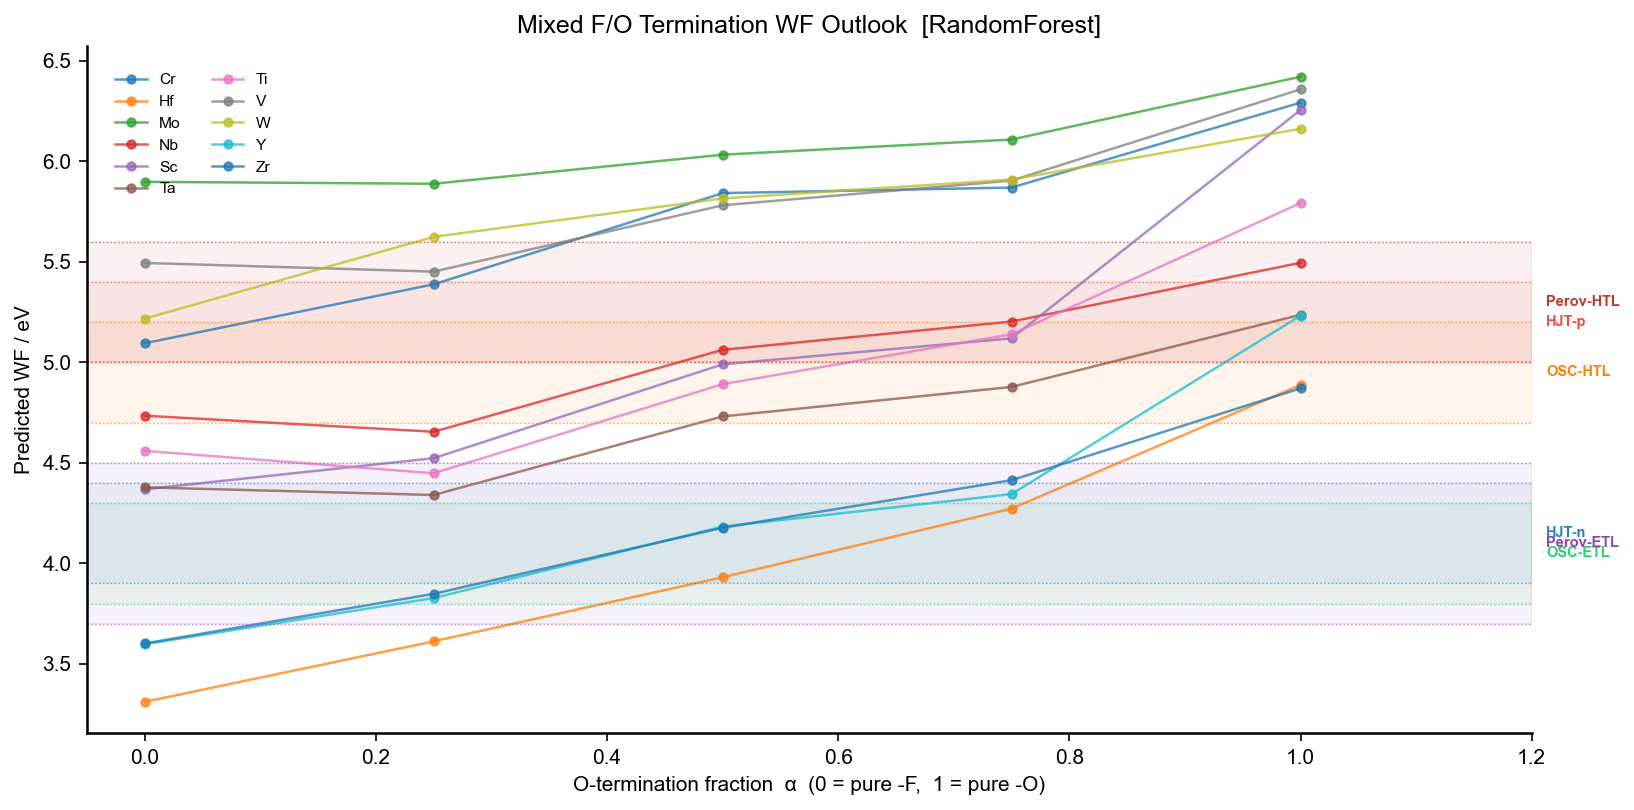

Saved: Table11_mixed_termination_WF.csv

[Fig11 Origin 导出]
  Saved: Fig11_panelA_violin_data.csv
  Saved: Fig11_panelA_stats.csv
  Saved: Fig11_panelA_OSC_reflines.csv
  Saved: Fig11_panelB_heatmap_long.csv
  Saved: Fig11_panelB_heatmap_wide.csv

[Fig15 Origin 导出]
  Saved: Fig15_mixed_term_wide.csv
  Saved: Fig15_mixed_term_long.csv
  Saved: Fig15_window_bands.csv

Cell 15 complete ✓
导出文件汇总：
  Fig11_panelA_violin_data.csv
  Fig11_panelA_stats.csv
  Fig11_panelA_OSC_reflines.csv
  Fig11_panelB_heatmap_long.csv
  Fig11_panelB_heatmap_wide.csv
  Fig15_mixed_term_wide.csv
  Fig15_mixed_term_long.csv
  Fig15_window_bands.csv
  Table11_mixed_termination_WF.csv


In [16]:
# ============================================================
# Cell 15  设计规则矩阵 + 混合终端展望 + Origin 导出
# ============================================================
print("=" * 60)
print("Cell 15: Design Rule Matrix + Mixed Termination Outlook")
print("=" * 60)

metal_order   = sorted(df[COL_M].unique())
term_order    = ["F", "O", "OH"]
term_colors_v = {"F": COLOR_BLUE, "O": COLOR_ORANGE, "OH": COLOR_GRAY}

# ── Panel A：Violin + Strip ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]

for i, term in enumerate(term_order):
    mask_t = df[COL_T] == term
    wf_t   = df.loc[mask_t, COL_Y].values

    parts = ax.violinplot(wf_t, positions=[i], widths=0.6,
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(term_colors_v[term])
        pc.set_alpha(0.5)
    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        parts[key].set_color(COLOR_GRAY)

    jitter = np.random.RandomState(42).uniform(-0.08, 0.08, mask_t.sum())
    ax.scatter(np.full(mask_t.sum(), i) + jitter, wf_t,
               color=term_colors_v[term], s=16,
               alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.text(i, float(wf_t.max()) + 0.15,
            f"n={int(mask_t.sum())}  μ={round(float(wf_t.mean()), 2)}",
            ha="center", va="bottom", fontsize=8)

# OSC HTL 窗口
ax.axhspan(OSC_WF_LO, OSC_WF_HI, alpha=0.10, color=COLOR_ORANGE)
ax.axhline(OSC_WF_LO, color=COLOR_ORANGE, lw=1.0, linestyle="--")
ax.axhline(OSC_WF_HI, color=COLOR_ORANGE, lw=1.0, linestyle="--",
           label=f"OSC-HTL [{OSC_WF_LO}-{OSC_WF_HI} eV]")

# OSC ETL 窗口
ax.axhspan(OSC_ETL_LO, OSC_ETL_HI, alpha=0.10, color="#2ECC71")
ax.axhline(OSC_ETL_LO, color="#2ECC71", lw=1.0, linestyle="--")
ax.axhline(OSC_ETL_HI, color="#2ECC71", lw=1.0, linestyle="--",
           label=f"OSC-ETL [{OSC_ETL_LO}-{OSC_ETL_HI} eV]")

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["-F", "-O", "-OH"], fontsize=11)
ax.set_ylabel("Work Function / eV")
ax.set_title("(a) WF Distribution by Termination")
ax.legend(frameon=False, fontsize=7.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Panel B：M × T 热图 ───────────────────────────────────────────────
ax2 = axes[1]
wf_matrix = np.full((len(metal_order), len(term_order)), np.nan)
for i, metal in enumerate(metal_order):
    for j, term in enumerate(term_order):
        mask_mt = (df[COL_M] == metal) & (df[COL_T] == term)
        if mask_mt.sum() > 0:
            wf_matrix[i, j] = df.loc[mask_mt, COL_Y].mean()

im2 = ax2.imshow(wf_matrix, cmap="RdYlBu_r",
                 vmin=1.0, vmax=8.0, aspect="auto")
plt.colorbar(im2, ax=ax2, label="Mean WF / eV",
             fraction=0.046, pad=0.04)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(["-F", "-O", "-OH"], fontsize=11)
ax2.set_yticks(range(len(metal_order)))
ax2.set_yticklabels(metal_order, fontsize=10)
ax2.set_title("(b) M x Termination WF Design Map  (mean DFT WF / eV)")

for i in range(len(metal_order)):
    for j in range(len(term_order)):
        if not np.isnan(wf_matrix[i, j]):
            txt_c = "white" if (wf_matrix[i,j] > 5.8
                                or wf_matrix[i,j] < 2.2) else "black"
            ax2.text(j, i, str(round(wf_matrix[i, j], 2)),
                     ha="center", va="center",
                     fontsize=7.5, color=txt_c)

plt.tight_layout()
save_fig("Fig11_design_rule_matrix")
plt.show()

# ── 混合终端展望（F/O 线性插值）─────────────────────────────────────
df_F = df[df[COL_T] == "F"].copy()
df_O = df[df[COL_T] == "O"].copy()
common_metals = sorted(
    set(df_F[COL_M].unique()) & set(df_O[COL_M].unique())
)

hypo_rows = []
for metal in common_metals:
    rows_F = df_F[df_F[COL_M] == metal]
    rows_O = df_O[df_O[COL_M] == metal]
    if len(rows_F) == 0 or len(rows_O) == 0:
        continue
    row_F = rows_F.iloc[0]
    row_O = rows_O.iloc[0]

    for alpha in [0.25, 0.50, 0.75]:
        row_mix = row_F.copy()
        for col in num_cols:
            try:
                row_mix[col] = ((1 - alpha) * float(row_F[col])
                                + alpha * float(row_O[col]))
            except Exception:
                pass
        row_mix[COL_T] = "F"
        row_mix[COL_M] = metal
        X_hypo = pd.DataFrame([row_mix[cat_cols + num_cols]])
        try:
            wf_pred = float(best_pipe.predict(X_hypo)[0])
        except Exception:
            wf_pred = float("nan")
        hypo_rows.append({
            "Metal":      metal,
            "Alpha_O":    alpha,
            "Mix_Label":  f"{metal}  α={alpha}",
            "WF_pred_eV": round(wf_pred, 4),
        })

df_hypo = pd.DataFrame(hypo_rows)

# ── 混合终端预测图 ────────────────────────────────────────────────────
if len(df_hypo) > 0:
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for metal in common_metals:
        sub = df_hypo[df_hypo["Metal"] == metal].sort_values("Alpha_O")
        wf_F_mean = float(df_F[df_F[COL_M] == metal][COL_Y].mean()) \
                    if len(df_F[df_F[COL_M] == metal]) > 0 else float("nan")
        wf_O_mean = float(df_O[df_O[COL_M] == metal][COL_Y].mean()) \
                    if len(df_O[df_O[COL_M] == metal]) > 0 else float("nan")

        alphas_full = [0.0] + list(sub["Alpha_O"]) + [1.0]
        wfs_full    = ([wf_F_mean]
                       + list(sub["WF_pred_eV"])
                       + [wf_O_mean])
        ax.plot(alphas_full, wfs_full,
                marker="o", markersize=4,
                linewidth=1.2, alpha=0.75,
                label=metal)

    # 六窗口色带
    window_bands = [
        (OSC_WF_LO,  OSC_WF_HI,  COLOR_ORANGE, "OSC-HTL"),
        (OSC_ETL_LO, OSC_ETL_HI, "#2ECC71",    "OSC-ETL"),
        (5.0,        5.6,        "#C0392B",    "Perov-HTL"),
        (3.7,        4.5,        "#8E44AD",    "Perov-ETL"),
        (5.0,        5.4,        "#E74C3C",    "HJT-p"),
        (3.9,        4.4,        "#2980B9",    "HJT-n"),
    ]
    for lo, hi, color, wlabel in window_bands:
        ax.axhspan(lo, hi, alpha=0.07, color=color)
        ax.axhline(lo, color=color, lw=0.7, linestyle=":", alpha=0.6)
        ax.axhline(hi, color=color, lw=0.7, linestyle=":", alpha=0.6)
        ax.text(1.01, (lo + hi) / 2, wlabel,
                transform=ax.get_yaxis_transform(),
                va="center", ha="left",
                fontsize=7, color=color, fontweight="bold")

    ax.set_xlabel("O-termination fraction  α  (0 = pure -F,  1 = pure -O)",
                  fontsize=10)
    ax.set_ylabel("Predicted WF / eV", fontsize=10)
    ax.set_title("Mixed F/O Termination WF Outlook  [" + best_name + "]",
                 fontsize=12)
    ax.set_xlim(-0.05, 1.20)
    ax.legend(frameon=False, fontsize=7.5,
              ncol=2, loc="upper left",
              bbox_to_anchor=(0.01, 0.98))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    save_fig("Fig15_mixed_termination_outlook")
    plt.show()

    df_hypo.to_csv(
        os.path.join(OUTDIR, "Table11_mixed_termination_WF.csv"),
        index=False, encoding="utf-8-sig"
    )
    print("Saved: Table11_mixed_termination_WF.csv")
else:
    print("Warning: df_hypo 为空，请检查 df_F / df_O")

# ── Origin 导出：Fig11 + Fig15 ────────────────────────────────────────
print("\n[Fig11 Origin 导出]")

# Panel A 原始数据
pd.DataFrame({
    "WF_F_eV":  pd.Series(df.loc[df[COL_T] == "F",  COL_Y].values),
    "WF_O_eV":  pd.Series(df.loc[df[COL_T] == "O",  COL_Y].values),
    "WF_OH_eV": pd.Series(df.loc[df[COL_T] == "OH", COL_Y].values),
}).to_csv(os.path.join(OUTDIR, "Fig11_panelA_violin_data.csv"),
          index=False, encoding="utf-8-sig")
print("  Saved: Fig11_panelA_violin_data.csv")

# Panel A 统计摘要
stat_rows_v = []
for term in ["F", "O", "OH"]:
    wf_t = df.loc[df[COL_T] == term, COL_Y].values
    stat_rows_v.append({
        "Termination": f"-{term}",
        "N":           len(wf_t),
        "Mean_eV":     round(float(np.mean(wf_t)),           4),
        "Median_eV":   round(float(np.median(wf_t)),         4),
        "Std_eV":      round(float(np.std(wf_t)),            4),
        "Q1_eV":       round(float(np.percentile(wf_t, 25)), 4),
        "Q3_eV":       round(float(np.percentile(wf_t, 75)), 4),
        "Min_eV":      round(float(wf_t.min()),              4),
        "Max_eV":      round(float(wf_t.max()),              4),
        "Color_Hex":   term_colors_v[term],
    })
pd.DataFrame(stat_rows_v).to_csv(
    os.path.join(OUTDIR, "Fig11_panelA_stats.csv"),
    index=False, encoding="utf-8-sig")
print("  Saved: Fig11_panelA_stats.csv")

# Panel A 参考线（OSC HTL + ETL）
pd.DataFrame([
    {"Window": "OSC-HTL_Lo", "WF_eV": OSC_WF_LO,  "Color_Hex": COLOR_ORANGE, "Line_Style": "Dash"},
    {"Window": "OSC-HTL_Hi", "WF_eV": OSC_WF_HI,  "Color_Hex": COLOR_ORANGE, "Line_Style": "Dash"},
    {"Window": "OSC-ETL_Lo", "WF_eV": OSC_ETL_LO, "Color_Hex": "#2ECC71",    "Line_Style": "Dash"},
    {"Window": "OSC-ETL_Hi", "WF_eV": OSC_ETL_HI, "Color_Hex": "#2ECC71",    "Line_Style": "Dash"},
]).to_csv(os.path.join(OUTDIR, "Fig11_panelA_OSC_reflines.csv"),
          index=False, encoding="utf-8-sig")
print("  Saved: Fig11_panelA_OSC_reflines.csv")

# Panel B 热图长表 + 宽表
heatmap_rows = []
for metal in metal_order:
    for term in ["F", "O", "OH"]:
        mask_mt = (df[COL_M] == metal) & (df[COL_T] == term)
        wf_mean = round(float(df.loc[mask_mt, COL_Y].mean()), 4) \
                  if mask_mt.sum() > 0 else float("nan")
        heatmap_rows.append({
            "Metal":       metal,
            "Termination": f"-{term}",
            "WF_mean_eV":  wf_mean,
            "N_samples":   int(mask_mt.sum()),
        })
df_heatmap = pd.DataFrame(heatmap_rows)
df_heatmap.to_csv(
    os.path.join(OUTDIR, "Fig11_panelB_heatmap_long.csv"),
    index=False, encoding="utf-8-sig")
df_heatmap.pivot(
    index="Metal", columns="Termination", values="WF_mean_eV"
).reindex(index=metal_order).to_csv(
    os.path.join(OUTDIR, "Fig11_panelB_heatmap_wide.csv"),
    encoding="utf-8-sig")
print("  Saved: Fig11_panelB_heatmap_long.csv")
print("  Saved: Fig11_panelB_heatmap_wide.csv")

print("\n[Fig15 Origin 导出]")
if len(df_hypo) > 0:
    # 宽表（含纯 F/O 端点）
    alpha_all = [0.0, 0.25, 0.50, 0.75, 1.0]
    wide_dict = {"Alpha_O": alpha_all}
    for metal in common_metals:
        wf_F_m = float(df_F[df_F[COL_M] == metal][COL_Y].mean()) \
                 if len(df_F[df_F[COL_M] == metal]) > 0 else float("nan")
        wf_O_m = float(df_O[df_O[COL_M] == metal][COL_Y].mean()) \
                 if len(df_O[df_O[COL_M] == metal]) > 0 else float("nan")
        sub = df_hypo[df_hypo["Metal"] == metal].sort_values("Alpha_O")
        wide_dict[f"WF_{metal}_eV"] = (
            [round(wf_F_m, 4)]
            + [round(v, 4) for v in sub["WF_pred_eV"]]
            + [round(wf_O_m, 4)]
        )
    pd.DataFrame(wide_dict).to_csv(
        os.path.join(OUTDIR, "Fig15_mixed_term_wide.csv"),
        index=False, encoding="utf-8-sig")
    print("  Saved: Fig15_mixed_term_wide.csv")

    # 长表（含端点）
    ep_rows = []
    for metal in common_metals:
        wf_F_m = float(df_F[df_F[COL_M] == metal][COL_Y].mean()) \
                 if len(df_F[df_F[COL_M] == metal]) > 0 else float("nan")
        wf_O_m = float(df_O[df_O[COL_M] == metal][COL_Y].mean()) \
                 if len(df_O[df_O[COL_M] == metal]) > 0 else float("nan")
        ep_rows += [
            {"Metal": metal, "Alpha_O": 0.0,
             "Mix_Label": f"{metal} α=0.0 (pure-F)",
             "WF_pred_eV": round(wf_F_m, 4)},
            {"Metal": metal, "Alpha_O": 1.0,
             "Mix_Label": f"{metal} α=1.0 (pure-O)",
             "WF_pred_eV": round(wf_O_m, 4)},
        ]
    pd.concat([df_hypo, pd.DataFrame(ep_rows)],
              ignore_index=True
    ).sort_values(["Metal", "Alpha_O"]).reset_index(drop=True).to_csv(
        os.path.join(OUTDIR, "Fig15_mixed_term_long.csv"),
        index=False, encoding="utf-8-sig")
    print("  Saved: Fig15_mixed_term_long.csv")

    # 六窗口色带参考表
    pd.DataFrame([
        {"Window": "OSC-HTL",   "WF_Lo_eV": OSC_WF_LO,  "WF_Hi_eV": OSC_WF_HI,  "WF_Mid_eV": round((OSC_WF_LO+OSC_WF_HI)/2,   3), "Color_Hex": COLOR_ORANGE},
        {"Window": "OSC-ETL",   "WF_Lo_eV": OSC_ETL_LO, "WF_Hi_eV": OSC_ETL_HI, "WF_Mid_eV": round((OSC_ETL_LO+OSC_ETL_HI)/2, 3), "Color_Hex": "#2ECC71"},
        {"Window": "Perov-HTL", "WF_Lo_eV": 5.0,         "WF_Hi_eV": 5.6,         "WF_Mid_eV": 5.30,                                 "Color_Hex": "#C0392B"},
        {"Window": "Perov-ETL", "WF_Lo_eV": 3.7,         "WF_Hi_eV": 4.5,         "WF_Mid_eV": 4.10,                                 "Color_Hex": "#8E44AD"},
        {"Window": "HJT-p",     "WF_Lo_eV": 5.0,         "WF_Hi_eV": 5.4,         "WF_Mid_eV": 5.20,                                 "Color_Hex": "#E74C3C"},
        {"Window": "HJT-n",     "WF_Lo_eV": 3.9,         "WF_Hi_eV": 4.4,         "WF_Mid_eV": 4.15,                                 "Color_Hex": "#2980B9"},
    ]).to_csv(os.path.join(OUTDIR, "Fig15_window_bands.csv"),
              index=False, encoding="utf-8-sig")
    print("  Saved: Fig15_window_bands.csv")

print("")
print("=" * 60)
print("Cell 15 complete ✓")
print("导出文件汇总：")
print("  Fig11_panelA_violin_data.csv")
print("  Fig11_panelA_stats.csv")
print("  Fig11_panelA_OSC_reflines.csv")
print("  Fig11_panelB_heatmap_long.csv")
print("  Fig11_panelB_heatmap_wide.csv")
print("  Fig15_mixed_term_wide.csv")
print("  Fig15_mixed_term_long.csv")
print("  Fig15_window_bands.csv")
print("  Table11_mixed_termination_WF.csv")
print("=" * 60)


In [17]:
print(df[abs(df[COL_Y] - 3.42853) < 0.001][
    ["name", COL_M, COL_X, COL_T, "n", COL_Y]
])


       name M_label X_label T_label  n   Wf_cal
76  Cr3N2F2      Cr       N       F  2  3.42853


Cell 16  SHAP for RF

Cell SI-A: RF SHAP Attribution (Supplementary Figure)
RF SHAP input shape : (197, 35)  (all 197 samples)
shap_vals_rf shape : (197, 35)
RF SHAP Top-7:


,feature,mean_abs_shap
0,En_T,0.262686
1,En_M,0.227719
2,Ip_T,0.209404
3,r_M,0.087471
4,r_T,0.071575
5,a,0.050166
6,VBM_PBE0,0.042665


  Saved: FigSI_SHAP_RF_vs_XGB_comparison.png / .tiff


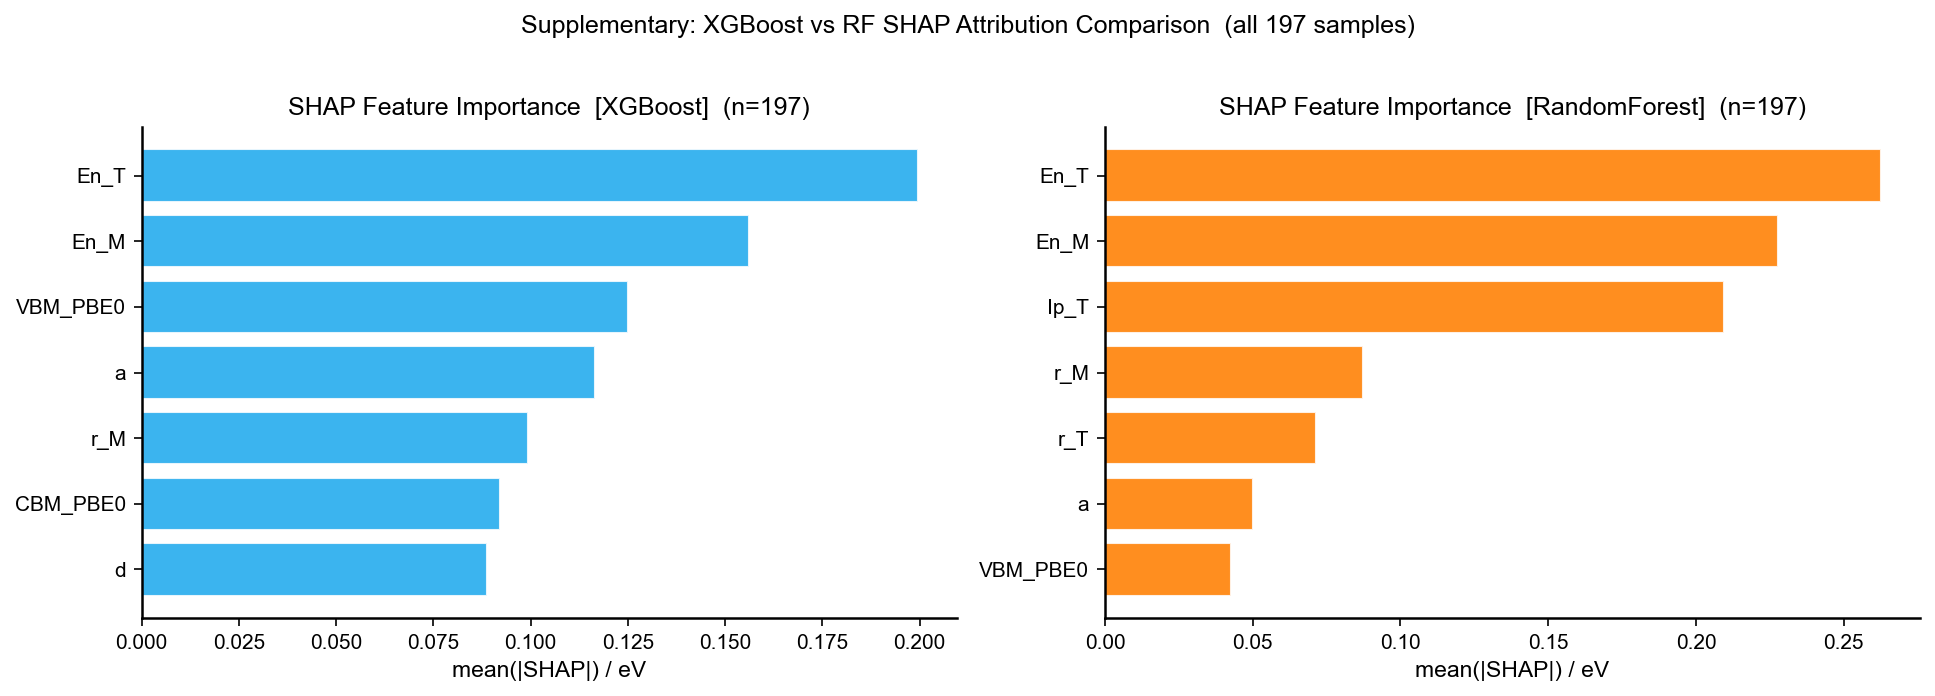


Top-4 descriptor ranking:
  XGBoost      : ['En_T', 'En_M', 'VBM_PBE0', 'a']
  RandomForest : ['En_T', 'En_M', 'Ip_T', 'r_M']
  Identical    : False
Saved: TableSI_SHAP_RF_top7.csv
Cell SI-A complete


In [27]:
# Cell SI-A  RF-based SHAP Global Feature Importance（对照图）
# 对应正文 Figure S×：RF SHAP top-7，与 XGBoost 结果对比
print("=" * 60)
print("Cell SI-A: RF SHAP Attribution (Supplementary Figure)")
print("=" * 60)

import shap
import numpy as np

TOPK_SI = 7

# ── 使用已训练的 RF pipeline ──────────────────────────────────────────
rf_pipe  = fitted["RandomForest"]
prep_rf  = rf_pipe.named_steps["prep"]
model_rf = rf_pipe.named_steps["model"]

# ── 转换全部197个样本（与 Cell 10 保持一致）──────────────────────────
X_all_trans_rf = prep_rf.transform(X)
try:
    X_all_trans_rf = X_all_trans_rf.toarray()
except Exception:
    pass

print("RF SHAP input shape : " + str(X_all_trans_rf.shape) + "  (all " + str(len(X)) + " samples)")

# ── 获取编码后特征名（与 Cell 10 一致）───────────────────────────────
ohe_rf        = prep_rf.named_transformers_["cat"]
feat_names_rf = list(ohe_rf.get_feature_names_out(cat_cols)) + list(num_cols)
n_ohe_rf      = sum(len(c) for c in ohe_rf.categories_)

# ── SHAP 计算（全样本）───────────────────────────────────────────────
explainer_rf = shap.TreeExplainer(model_rf)
shap_vals_rf = explainer_rf.shap_values(X_all_trans_rf)

print("shap_vals_rf shape : " + str(shap_vals_rf.shape))

# ── 聚合：one-hot → 原始列 ────────────────────────────────────────────
mean_abs_rf   = np.abs(shap_vals_rf).mean(axis=0)
group_rows_rf = []
start = 0
for col, sz in zip(cat_cols, [len(c) for c in ohe_rf.categories_]):
    group_rows_rf.append([col, float(mean_abs_rf[start:start+sz].sum())])
    start += sz
for j, col in enumerate(num_cols):
    group_rows_rf.append([col, float(mean_abs_rf[n_ohe_rf + j])])

df_shap_rf = pd.DataFrame(
    group_rows_rf, columns=["feature", "mean_abs_shap"]
).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

EXCLUDE_LABELS = {"M_label", "X_label", "T_label"}
df_shap_rf_topk = df_shap_rf[
    ~df_shap_rf["feature"].isin(EXCLUDE_LABELS)
].head(TOPK_SI).copy().reset_index(drop=True)

print("RF SHAP Top-" + str(TOPK_SI) + ":")
display(df_shap_rf_topk)

# ── 对比图：XGBoost vs RF ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (df_plot_s, model_name, color) in zip(axes, [
    (df_shap_topk,    "XGBoost",      COLOR_BLUE),
    (df_shap_rf_topk, "RandomForest", COLOR_ORANGE),
]):
    df_rev = df_plot_s.iloc[::-1]
    ax.barh(
        df_rev["feature"], df_rev["mean_abs_shap"],
        color=color, alpha=0.88, edgecolor="white"
    )
    ax.set_xlabel("mean(|SHAP|) / eV")
    ax.set_title("SHAP Feature Importance  [" + model_name + "]  (n=197)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Supplementary: XGBoost vs RF SHAP Attribution Comparison  (all 197 samples)",
    fontsize=12, y=1.02
)
plt.tight_layout()
save_fig("FigSI_SHAP_RF_vs_XGB_comparison")
plt.show()

# ── 验证 top-4 排序一致性 ─────────────────────────────────────────────
top4_xgb = df_shap_topk["feature"].head(4).tolist()
top4_rf  = df_shap_rf_topk["feature"].head(4).tolist()
print("")
print("Top-4 descriptor ranking:")
print("  XGBoost      : " + str(top4_xgb))
print("  RandomForest : " + str(top4_rf))
print("  Identical    : " + str(top4_xgb == top4_rf))

# ── 保存 ─────────────────────────────────────────────────────────────
df_shap_rf_topk.to_csv(
    os.path.join(OUTDIR, "TableSI_SHAP_RF_top7.csv"),
    index=False, encoding="utf-8-sig"
)
print("Saved: TableSI_SHAP_RF_top7.csv")
print("Cell SI-A complete")


Cell VBM_PBE0对应的金属性/半导体性分类散点图

Cell SI-B: VBM_PBE0 SHAP Sign Reversal Classification
VBM_PBE0 SHAP zero crossing(s): [-1.424]
  Saved: FigSI_VBM_PBE0_SHAP_classification.png / .tiff


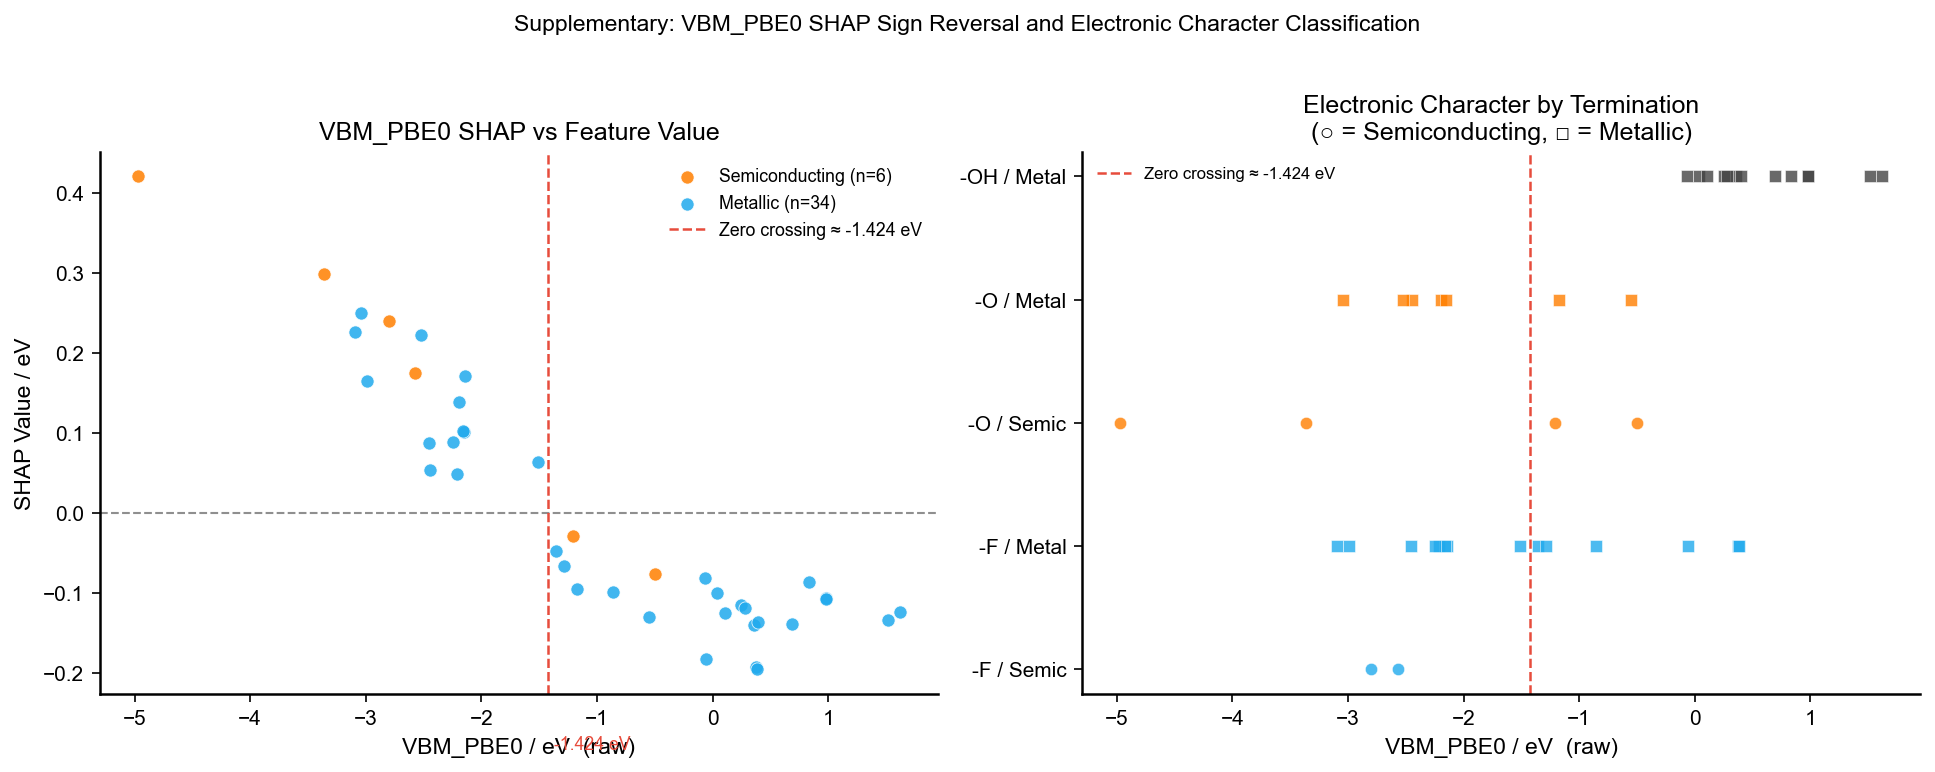


[Origin CSV 导出]
  Saved: FigSI_B_left_scatter_by_gap.csv
  Saved: FigSI_B_left_reflines.csv
  Saved: FigSI_B_left_scatter_by_term.csv
  Saved: FigSI_B_right_strip_data.csv
  Saved: FigSI_B_right_strip_wide.csv
  Saved: TableSI_VBM_PBE0_SHAP_classification.csv  (full summary)

--------------------------------------------------
Origin 导出完毕，共 6 个 CSV：
  ① FigSI_B_left_scatter_by_gap.csv   ← 左图：按 IsGap 分组散点
  ② FigSI_B_left_reflines.csv         ← 左图：参考线位置
  ③ FigSI_B_left_scatter_by_term.csv  ← 左图：按终端分组（可选）
  ④ FigSI_B_right_strip_data.csv      ← 右图：长表格式
  ⑤ FigSI_B_right_strip_wide.csv      ← 右图：宽表格式（推荐）
  ⑥ TableSI_VBM_PBE0_SHAP_classification.csv  ← 完整汇总
--------------------------------------------------

Zero crossing value for manuscript: -1.424 eV
Cell SI-B complete ✓


In [21]:
# Cell SI-B  VBM_PBE0 SHAP sign reversal + 金属性/半导体性分类图
# 对应正文 Figure S×：VBM_PBE0 SHAP 值 vs 描述符数值，按 IsGap 分色
print("=" * 60)
print("Cell SI-B: VBM_PBE0 SHAP Sign Reversal Classification")
print("=" * 60)

import shap
import numpy as np

# ── 复用 Cell 10 的 SHAP 值 ───────────────────────────────────────────
vbm_idx      = num_cols.index("VBM_PBE0")
shap_vbm     = shap_vals[:, n_ohe + vbm_idx]
feat_vbm     = X_test_trans[:, n_ohe + vbm_idx]

# 反标准化还原原始 VBM_PBE0 数值
scaler_num   = prep_shap.named_transformers_["num"]
vbm_col_idx  = num_cols.index("VBM_PBE0")
vbm_mean     = scaler_num.mean_[vbm_col_idx]
vbm_std      = scaler_num.scale_[vbm_col_idx]
feat_vbm_raw = feat_vbm * vbm_std + vbm_mean

# ── 获取测试集的 IsGap 标签 ───────────────────────────────────────────
isgap_test   = X_test["IsGap"].values.astype(float)
labels_test  = np.where(isgap_test == 1, "Semiconducting", "Metallic")
term_col_test_arr = X_test[COL_T].values

# ── 零交叉点计算 ──────────────────────────────────────────────────────
sort_idx    = np.argsort(feat_vbm_raw)
feat_sorted = feat_vbm_raw[sort_idx]
shap_sorted = shap_vbm[sort_idx]

zero_crossings = []
for i in range(len(shap_sorted) - 1):
    if shap_sorted[i] * shap_sorted[i+1] < 0:
        x0 = feat_sorted[i]
        x1 = feat_sorted[i+1]
        y0 = shap_sorted[i]
        y1 = shap_sorted[i+1]
        xc = x0 - y0 * (x1 - x0) / (y1 - y0)
        zero_crossings.append(round(float(xc), 3))

print(f"VBM_PBE0 SHAP zero crossing(s): {zero_crossings}")
zero_val = zero_crossings[0] if zero_crossings else None

# ── 绘图 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
color_map  = {"Semiconducting": COLOR_ORANGE, "Metallic": COLOR_BLUE}

ax1 = axes[0]
for label in ["Semiconducting", "Metallic"]:
    mask_l = labels_test == label
    ax1.scatter(
        feat_vbm_raw[mask_l], shap_vbm[mask_l],
        color=color_map[label],
        s=40, alpha=0.85,
        edgecolor="white", linewidth=0.4,
        label=label + f" (n={int(mask_l.sum())})",
        zorder=3
    )

ax1.axhline(0, color=COLOR_GRAY, lw=1.0, linestyle="--", alpha=0.6)
if zero_val is not None:
    ax1.axvline(
        zero_val,
        color=COLOR_RED, lw=1.2, linestyle="--",
        label=f"Zero crossing ≈ {zero_val} eV"
    )
    ax1.text(
        zero_val + 0.05, -0.3,
        f"{zero_val} eV",
        color=COLOR_RED, fontsize=8.5, va="bottom"
    )

ax1.set_xlabel("VBM_PBE0 / eV  (raw)")
ax1.set_ylabel("SHAP Value / eV")
ax1.set_title("VBM_PBE0 SHAP vs Feature Value")
ax1.legend(frameon=False, fontsize=8.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2 = axes[1]
for term in ["F", "O", "OH"]:
    mask_t = term_col_test_arr == term
    for label, marker in [("Semiconducting", "o"), ("Metallic", "s")]:
        mask_l = labels_test == label
        mask   = mask_t & mask_l
        if mask.sum() == 0:
            continue
        ax2.scatter(
            feat_vbm_raw[mask],
            [f"-{term} / {label[:5]}"] * mask.sum(),
            color=term_colors[term],
            marker=marker,
            s=35, alpha=0.80,
            edgecolor="white", linewidth=0.3
        )

if zero_val is not None:
    ax2.axvline(
        zero_val,
        color=COLOR_RED, lw=1.2, linestyle="--",
        label=f"Zero crossing ≈ {zero_val} eV"
    )

ax2.set_xlabel("VBM_PBE0 / eV  (raw)")
ax2.set_title("Electronic Character by Termination\n(○ = Semiconducting, □ = Metallic)")
ax2.legend(frameon=False, fontsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle(
    "Supplementary: VBM_PBE0 SHAP Sign Reversal and Electronic Character Classification",
    fontsize=11, y=1.02
)
plt.tight_layout()
save_fig("FigSI_VBM_PBE0_SHAP_classification")
plt.show()

# ════════════════════════════════════════════════════════════
# Origin 导出部分
# ════════════════════════════════════════════════════════════
print("\n[Origin CSV 导出]")

# ── CSV 1：左图原始数据（按电子结构类型分组）────────────────────────
# Origin 用法：两组数据分别画散点，X = VBM_PBE0_eV，Y = SHAP_eV
df_left_semi = pd.DataFrame({
    "VBM_PBE0_Semiconducting_eV": np.where(
        labels_test == "Semiconducting",
        np.round(feat_vbm_raw, 4), np.nan
    ),
    "SHAP_Semiconducting_eV": np.where(
        labels_test == "Semiconducting",
        np.round(shap_vbm, 4), np.nan
    ),
    "VBM_PBE0_Metallic_eV": np.where(
        labels_test == "Metallic",
        np.round(feat_vbm_raw, 4), np.nan
    ),
    "SHAP_Metallic_eV": np.where(
        labels_test == "Metallic",
        np.round(shap_vbm, 4), np.nan
    ),
})
df_left_semi.to_csv(
    os.path.join(OUTDIR, "FigSI_B_left_scatter_by_gap.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: FigSI_B_left_scatter_by_gap.csv")

# ── CSV 2：左图参考线位置 ────────────────────────────────────────────
# Origin 用法：添加水平线 y=0 和垂直线 x=zero_val
ref_lines = [
    {"Line_type": "Horizontal", "Position_eV": 0.0,
     "Color": COLOR_GRAY, "Style": "Dash", "Label": "y = 0"},
]
if zero_val is not None:
    ref_lines.append(
        {"Line_type": "Vertical", "Position_eV": zero_val,
         "Color": COLOR_RED, "Style": "Dash",
         "Label": f"Zero crossing = {zero_val} eV"}
    )
pd.DataFrame(ref_lines).to_csv(
    os.path.join(OUTDIR, "FigSI_B_left_reflines.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: FigSI_B_left_reflines.csv")

# ── CSV 3：左图按终端分色的原始数据（可选替代方案）──────────────────
# Origin 用法：三组散点按终端分色，形状区分金属性/半导体性
df_left_term = pd.DataFrame({
    "VBM_PBE0_eV":      np.round(feat_vbm_raw, 4),
    "SHAP_VBM_PBE0_eV": np.round(shap_vbm,     4),
    "Termination":      term_col_test_arr,
    "Electronic_char":  labels_test,
    "IsGap":            isgap_test.astype(int),
})
df_left_term.to_csv(
    os.path.join(OUTDIR, "FigSI_B_left_scatter_by_term.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: FigSI_B_left_scatter_by_term.csv")

# ── CSV 4：右图数据（每个终端×电子结构类型组合的 VBM_PBE0 分布）────
# Origin 用法：六组数据各画一列点，X = VBM_PBE0_eV，Y 轴为分组标签
right_rows = []
for term in ["F", "O", "OH"]:
    mask_t = term_col_test_arr == term
    for label in ["Semiconducting", "Metallic"]:
        mask_l = labels_test == label
        mask   = mask_t & mask_l
        if mask.sum() == 0:
            continue
        for val in feat_vbm_raw[mask]:
            right_rows.append({
                "Group_label":  f"-{term} / {label[:5]}",
                "Termination":  term,
                "Electronic_char": label,
                "VBM_PBE0_eV": round(float(val), 4),
            })

df_right = pd.DataFrame(right_rows)
df_right.to_csv(
    os.path.join(OUTDIR, "FigSI_B_right_strip_data.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: FigSI_B_right_strip_data.csv")

# ── CSV 5：右图宽表（每个 Group 一列，Origin 直接导入）───────────────
group_labels = []
for term in ["F", "O", "OH"]:
    for label in ["Semiconducting", "Metallic"]:
        mask = (term_col_test_arr == term) & (labels_test == label)
        if mask.sum() > 0:
            group_labels.append((f"-{term}_{label[:5]}", feat_vbm_raw[mask]))

max_len = max(len(v) for _, v in group_labels)
wide_dict = {}
for col_name, vals in group_labels:
    padded = list(np.round(vals, 4)) + [np.nan] * (max_len - len(vals))
    wide_dict[col_name] = padded

pd.DataFrame(wide_dict).to_csv(
    os.path.join(OUTDIR, "FigSI_B_right_strip_wide.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: FigSI_B_right_strip_wide.csv")

# ── CSV 6：完整汇总表（两图所有数据合并）────────────────────────────
df_summary = pd.DataFrame({
    "VBM_PBE0_raw_eV":   np.round(feat_vbm_raw, 4),
    "SHAP_VBM_PBE0_eV":  np.round(shap_vbm,     4),
    "IsGap":             isgap_test.astype(int),
    "Electronic_char":   labels_test,
    "Termination":       term_col_test_arr,
    "Metal":             X_test[COL_M].values,
    "n":                 X_test["n"].values,
})
df_summary.to_csv(
    os.path.join(OUTDIR, "TableSI_VBM_PBE0_SHAP_classification.csv"),
    index=False, encoding="utf-8-sig"
)
print("  Saved: TableSI_VBM_PBE0_SHAP_classification.csv  (full summary)")

# ── 导出汇总 ──────────────────────────────────────────────────────────
print("\n" + "-" * 50)
print("Origin 导出完毕，共 6 个 CSV：")
print("  ① FigSI_B_left_scatter_by_gap.csv   ← 左图：按 IsGap 分组散点")
print("  ② FigSI_B_left_reflines.csv         ← 左图：参考线位置")
print("  ③ FigSI_B_left_scatter_by_term.csv  ← 左图：按终端分组（可选）")
print("  ④ FigSI_B_right_strip_data.csv      ← 右图：长表格式")
print("  ⑤ FigSI_B_right_strip_wide.csv      ← 右图：宽表格式（推荐）")
print("  ⑥ TableSI_VBM_PBE0_SHAP_classification.csv  ← 完整汇总")
print("-" * 50)
print(f"\nZero crossing value for manuscript: {zero_val} eV")
print("Cell SI-B complete ✓")
